# 03 · Experiment plan: what the data constrain today and what to measure next

A **tentative** plan for the TMSPA experiments, **with big assumptions and limitatins**. 


It answers four questions: 
   1. what the model needs from experiment (1)
   2. what the data we already have determine (2–3)
   3. Where the model already disagrees with observations (4–5)
   4. which experiments, nuclei and time resolution would determine the rest (§6–9).

Theory: [docs/theory-multiscale_microkinetics.md](../docs/theory-multiscale_microkinetics.md) · data: [data/README.md](../data/README.md) · code: `kinetics/fitting/` (bounds and experiment design), `kinetics/reactor/validation.py` (checks against Gogoi 2024)


Today's data fix one family and bound two:

The four control experiments of Gogoi 2024 give:
   - solvent attack g = 1.27–1.39 eV
   - condensation g ≥ 1.24 eV 
   - transfer g ≤ 1.13 eV. 
They say nothing about hydrolysis (the reaction that sets the time scale of every TMSPA experiment)

A single global barrier ($E_0$) fails three of the four controls, so per-family barriers are required (but remember, those controls are based on some important assumptions)


**Problems:**

1. The model cannot reproduce the existing TMSPA + water observations at any barrier values.
   In Gogoi's water series, TMSPA survives at 1 vol% water but is gone at 2 vol%.
   --> The first experiment must test the hydrolysis rate law itself, not only fit its barrier.


2. The step protocol with room-temperature spectra only works in a narrow barrier window (Autogenerated, **not checked**)
  Hydrolysis g ≈ 1.25–1.40 eV. It has no early time points, and pure EC freezes at room temperature. Spectra recorded in the magnet at 40 °C, then 60 and 80 °C, cover every hydrolysis step for g ≈ 1.10–1.35 eV.

---
(under review, this was autogenerated)

1. Proposed plan, in priority order
   - **C**: TMSPA + 2 vol% H₂O, in situ 40 → 60 → 80 °C.
   - **D**: the same with a quarter of the water, which tests the rate law.
   - **E**: TMSPA + TMSOH in dry EC, for transfer.
   - **F**: TMSOH in dry EC at 80 °C, for condensation and solvent attack.
   - **C′**: C again, started at 50 °C, for ΔS‡ of the first step (§7.5).

   ³¹P every 5 min carries the kinetics. ²⁹Si every 30 min follows TMSOH, TMS-EG and HMDSO. Both cadences are placeholders (§6.1).


1. **Two checks on the plan.** With ΔS‡ free, C alone gives ΔS‡ of R2 and R3 but not of R1, which C′ adds (§7.5). The CO₂ from EC ring-opening can reach up to 15 bar in a sealed tube in F (upper bound, §8.1).
2. **What the plan would determine:** the barrier of each hydrolysis step, down to the ~2 meV systematic floor, plus condensation and solvent attack. Transfer is determined only if its true g ≥ 0.9 eV. The measured quantity is ΔG‡ per step. Turning it into a transferable family g needs the solvation uncertainty (SLV-01) resolved first.

---

**Assumptions**
- Model `level1`: Marcus barriers, one intrinsic barrier g per family, ΔS‡ = 0. The thermochemistry is computed (ωB97M-V G at 298 K + MACE ΔE_solv in EC). EC is the solvent at constant concentration, and the sample is one homogeneous phase.
- Gogoi 2024 used EC/DEC 1:1; we simulate it with [EC] = 7.1 M and the solvation of pure EC. 
- Windows marked `assumed` rest on a detection limit or a time the paper does not give. Windows marked `reading` are our reading of a qualitative description.
- (Autogenerated) The NMR acquisition times and noise in 6 are assumptions to confirm with the NMR facility. The precision of 7 is local (it holds for the stated true values) and counts only the noise of the peak integrals.

In [1]:
%load_ext autoreload
%autoreload 2

import copy
import sys
from pathlib import Path

# Make the repository importable whether the notebook runs from notebooks/ or from the repository root
REPO = Path.cwd() if (Path.cwd() / 'kinetics').is_dir() else Path.cwd().parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
from IPython.display import display

from kinetics import (
    MODELS,                         # List of available models  
    build_protocol_schedule,        # Builds a schedule of stages from a protocol [not checked]
    calculate_network_thermo,       # Computes reaction thermodynamics for the whole reaction network at T
    calculate_recipe_molarities,    # Converts the recupe (water, TMSPA fractions, etc.) into molarities of all species in the network [not checked]
    calculate_remaining_fraction,   # Computes the remaining fraction of a species after a protocol [not checked]
    evaluate_control_experiments,   # Simulates every control experiment with every model and compares with the observed window [not checked]
    get_model,                      # Retrieve a model by name
    load_experimental_data,         # Loads the experimental data from the file
    simulate_protocol,              # Simulates a protocol with a given model and returns the time series of species concentrations [not checked]
)

from kinetics.data import calculate_molar_mass, get_water_series # [not checked]
from kinetics.reactor.protocol import DEFAULT_DENSITY_G_ML # [not checked]
from kinetics.microkinetics import tabulate_family_barriers # [not checked]
from kinetics.reactor import calculate_worst_case_pressure_bar, evaluate_heating_observation, evaluate_water_series # [not checked]
from kinetics.fitting import (
    DEFAULT_ACQUISITION, FAMILIES, NMR_READOUTS, add_readout_noise, build_composition, build_in_situ_design,
    build_isothermal_design, build_step_design, calculate_barrier_error_budget, calculate_eyring_precision,
    calculate_half_life_map, compare_designs, describe_designs, find_barrier_bounds, get_family_parameter,
    project_bounds_to_entropy, scan_design_precision, scan_family_barriers, simulate_design, split_family_by_reaction,
    summarize_feasible_intervals, find_unread_species, tabulate_readout_evidence,
) # [not checked]
from demo import design_plots, reactor_plots, style, tables, thermo_plots

style.apply_style()
pd.set_option('display.max_colwidth', None)

## 1. What has to be determined

Used model is `level1`: Marcus barriers with one intrinsic barrier g per reaction family and ΔS‡ = 0. 

[g is the parameter the experiments must fit] 

Everything else in the first table is computed. The table lists every reaction with its computed ΔG_rxn and the provisional solvation σ.

The figure shows how much solvation in EC moves each ΔG_rxn. The second table shows the g of each family in every registered model and what the `level1` value rests on.

level1 [provisional]: Level 1: Marcus with recalibrated family barriers
  - Condensation g = 1.30 eV and solvent attack g = 1.32 eV are derived from Gogoi et al. 2024
  - Hydrolysis and transfer g = 0.80 eV are placeholders (Finding 18): TMSPA is consumed within the first 20 °C hold


,family,equation,ΔG_rxn (eV),σ solvation (eV),g (eV) ← TO FIT,source of g,ΔG‡ at 25 °C (eV)
R1,hydrolysis,TMSPA + H2O ⇌ BMSPA + TMSOH,-0.474,0.26,0.80,Placeholder from Broqvist tank_model.ipynb; no quantitative anchor yet,0.580
R2,hydrolysis,BMSPA + H2O ⇌ MMSPA + TMSOH,-0.158,0.25,0.80,Placeholder from Broqvist tank_model.ipynb; no quantitative anchor yet,0.723
R3,hydrolysis,MMSPA + H2O ⇌ H3PO4 + TMSOH,-0.177,0.24,0.80,Placeholder from Broqvist tank_model.ipynb; no quantitative anchor yet,0.714
R4,condensation,2 TMSOH ⇌ HMDSO + H2O,+0.102,0.34,1.30,"No TMSOTMS from TMSOH alone after 8 h at 80 °C (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); uncatalysed channel only; derived",1.351
R5,transfer,TMSPA + TMSOH ⇌ BMSPA + HMDSO,-0.373,0.25,0.80,"Upper bound from TMSPa + TMSOH consumption at RT (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); derived",0.624
R6,transfer,BMSPA + TMSOH ⇌ MMSPA + HMDSO,-0.056,0.23,0.80,"Upper bound from TMSPa + TMSOH consumption at RT (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); derived",0.772
R7,transfer,MMSPA + TMSOH ⇌ H3PO4 + HMDSO,-0.076,0.23,0.80,"Upper bound from TMSPa + TMSOH consumption at RT (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); derived",0.763
R8,solvent_attack,EC + TMSOH ⇌ TMSOEG + CO2,-0.047,0.40,1.32,"EC ring-opening by TMSOH absent at RT, clear after 8 h at 80 °C (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); derived",1.297
R9,solvent_attack,EC + TMSOEG ⇌ TMSOdiEG + CO2,-0.467,0.44,1.32,"EC ring-opening by TMSOH absent at RT, clear after 8 h at 80 °C (Gogoi et al., J. Phys. Chem. C 2024, 128, 1654); derived",1.097


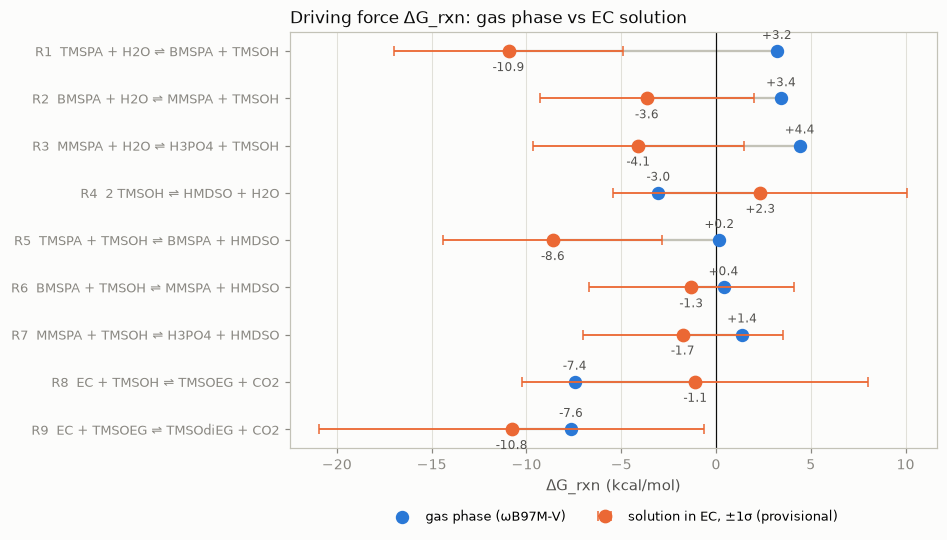

In [2]:
BASE_MODEL = 'level1'
model = get_model(BASE_MODEL)
print(f'{model.name} [{model.status}]: {model.label}')
for assumption in model.assumptions:
    print(f'  - {assumption}')

thermo = calculate_network_thermo(298.15)
rates_25C = model.calculate_rates(298.15)
parameter_table = pd.DataFrame({
    'family': thermo['class'],
    'equation': thermo['equation'],
    'ΔG_rxn (eV)': thermo['dG_rxn_eV'],
    'σ solvation (eV)': thermo['sigma_solv_eV'],
    'g (eV) ← TO FIT': [get_family_parameter(model, c) for c in thermo['class']], # initial guess
    'source of g': [model.family_params[c]['source'] for c in thermo['class']],
    'ΔG‡ at 25 °C (eV)': rates_25C['dG_barrier_f_eV'],        # Marcus: g · (1 + ΔG_rxn / 4g)²
})

thermo_plots.plot_solvation_dumbbell(thermo);

display(tables.format_columns(parameter_table, {'ΔG_rxn (eV)': '+.3f', 'σ solvation (eV)': '.2f',
                                                'g (eV) ← TO FIT': '.2f', 'ΔG‡ at 25 °C (eV)': '.3f'}))

In [3]:
LEVEL1_STATUS = {    # what the level1 value of g rests on; §3 turns this into bounds
    'hydrolysis': 'placeholder: no data constrain it',
    'condensation': 'derived from Gogoi E3 (lower bound)',
    'transfer': 'placeholder below the upper bound from Gogoi E4',
    'solvent_attack': 'derived from Gogoi E1 and E2',
}
family_table = tables.format_family_barriers(tabulate_family_barriers(list(MODELS)))
family_table['status (level1 g)'] = family_table.index.map(LEVEL1_STATUS)
family_table

,reactions,peter_reference,family_bep,family_marcus,level1,status (level1 g)
hydrolysis,"R1, R2, R3",1.15,0.80,0.80,0.80,placeholder: no data constrain it
condensation,R4,1.15,0.80,0.80,1.30,derived from Gogoi E3 (lower bound)
transfer,"R5, R6, R7",1.15,0.80,0.80,0.80,placeholder below the upper bound from Gogoi E4
solvent_attack,"R8, R9",1.15,1.30,1.30,1.32,derived from Gogoi E1 and E2


**Reading**
- Four intrinsic barriers (plus four ΔS‡, now zero) set every time scale in the network. A change of 0.06 eV in g changes a rate constant tenfold at 25 °C, so the barriers must be known to a few hundredths of an eV to predict hours versus days [AI: check]
- g can be learned from data. The Brønsted slope α of a family cannot, because the ΔG_rxn values in a family are too close together
- **Careful, solvation $\sigma$ decides the sign of most driving forces.** 
- The σ of ΔG_rxn is 0.23–0.44 eV (if the values are raw standard deviations). This does not affect a measured ΔG‡, but it does affect the g derived from it (7.3).

## 2. What data we have

Every source in the repository and what it can and cannot constrain; then the four control experiments of Gogoi et al. 2024 against each registered model; then what the literature says about whether each reaction happens at all.

How the controls are compared with the model? Gogoi report what they saw, so each control becomes a *fraction* and a *window*:
- What is in the tube:
  - E1–E3: only TMSOH in EC (0.45 M). 
  - E4: TMSPA (0.15 M) and TMSOH (0.18 M) in EC.


- Fraction (0–1), computed from the simulated tube at the end of the run:
  - E1, E2 (ring-opening of EC) = (TMSOEG + TMSOdiEG) / TMSOH₀. Each ring-opened product carries one TMS group.
  - E3 (condensation) = 2 · HMDSO / TMSOH₀. HMDSO carries two Si. E1–E3 are therefore a silicon balance over the TMSOH added.
  - E4 (transfer) = 1 − TMSPA / TMSPA₀, the TMSPA consumed.


- Window = the range of the fraction compatible with what Gogoi saw. It is our **interpretation of a qualitative statement**: 
  - "no ring-opening" --> ≤ 0.02 (E1), 
  - "clearly formed" --> 0.05–0.9 (E2), 
  - "impurity level only" --> ≤ 0.05 (E3), 
  - "no longer detectable" --> ≥ 0.95 (E4).

**The paper gives none of these numbers**. The data file labels E1 and E2 `derived` and E3 and E4 `assumed`, but in all four the numeric limit is our choice, so the bounds of Block 3 are only as firm as these limits (3.1 shows they move g by 0.03–0.08 eV).

In [4]:
inventory = pd.DataFrame([
    ['Tank snapshot (Broqvist)', 'computed', 'G (ωB97M-V), ΔE_solv (MACE MD in EC), NMR shieldings',
     'ΔG_rxn; peak positions for comparison only (§6.1)', 'no: no time or concentration'],
    ['Gogoi 2024, shifts', 'measured', '³¹P, ²⁹Si, ¹³C and ¹H shifts in EC/DEC', 'which peaks a fit can read (§6.1)', 'no'],
    ['Gogoi 2024, controls E1–E4', 'measured, qualitative', 'four mixtures, one observation each',
     'windows on one observable', 'as bounds (§3)'],
    ['Gogoi 2024, water series', 'measured, qualitative', '³¹P of TMSPA with 0.5–5 vol% H₂O; heating to 80 °C',
     'speciation at an unstated time', 'as a test of the model structure (§4)'],
    ['Ångström group (Erik)', 'pending', 'time-resolved NMR', '—', 'the fit itself'],
], columns=['source', 'kind', 'content', 'gives', 'usable for kinetics'])
print('Inventory of all data:')
display(inventory)
print("""There is no data for C(t), only "pictures""")

print("-------------------------------")

print("""Control experiments (Gogoi 2024)
For each model and each control E1–E4:
  1. Simulate Gogoi experiment in same conditions (mix, temperature, time);
  2. Calculate the observable measured by Gogoi (e.g. open EC fraction);
  3. Check if it falls within the observed window: ✓ or ✕.
""")
checks = evaluate_control_experiments(list(MODELS))
display(tables.format_control_checks(checks))

Inventory of all data:


,source,kind,content,gives,usable for kinetics
0,Tank snapshot (Broqvist),computed,"G (ωB97M-V), ΔE_solv (MACE MD in EC), NMR shieldings",ΔG_rxn; peak positions for comparison only (§6.1),no: no time or concentration
1,"Gogoi 2024, shifts",measured,"³¹P, ²⁹Si, ¹³C and ¹H shifts in EC/DEC",which peaks a fit can read (§6.1),no
2,"Gogoi 2024, controls E1–E4","measured, qualitative","four mixtures, one observation each",windows on one observable,as bounds (§3)
3,"Gogoi 2024, water series","measured, qualitative",³¹P of TMSPA with 0.5–5 vol% H₂O; heating to 80 °C,speciation at an unstated time,as a test of the model structure (§4)
4,Ångström group (Erik),pending,time-resolved NMR,—,the fit itself


There is no data for C(t), only "pictures
-------------------------------
Control experiments (Gogoi 2024)
For each model and each control E1–E4:
  1. Simulate Gogoi experiment in same conditions (mix, temperature, time);
  2. Calculate the observable measured by Gogoi (e.g. open EC fraction);
  3. Check if it falls within the observed window: ✓ or ✕.



,conditions,observable,observed window,peter_reference,family_bep,family_marcus,level1
E1,"TMSOH in EC, RT, 1 week",TMSOH ring-opened into TMSOEG + TMSOdiEG (fraction),≤ 0.02 (derived),0.617 ✗,0.00221 ✓,0.00551 ✓,0.00323 ✓
E2,"TMSOH in EC, 8 h at 80 °C",TMSOH ring-opened into TMSOEG + TMSOdiEG (fraction),≥ 0.05 and ≤ 0.9 (derived),0.989 ✗,0.264 ✓,0.485 ✓,0.375 ✓
E3,"TMSOH in EC, 8 h at 80 °C",Si of TMSOH ending in HMDSO (fraction),≤ 0.05 (assumed),0.0106 ✓,0.201 ✗,0.141 ✗,0.00636 ✓
E4,"TMSPA + TMSOH in EC, RT, 24 h",TMSPA converted (fraction),≥ 0.95 (assumed),0.00327 ✗,1 ✓,1 ✓,1 ✓


`level1` passing E1-E4 **proves nothing**, but demostrate that is the only model that pases the 4 controls:

- We are using the same data to set a value and test it!!!!!!


**Example:**
- E1 says little or no EC opening at room T. That only holds if g >= 1.27eV
- E2 says some opening after 8h at 80ºC. That only holds if g <= 1.39eV
- `level1`sets at g=1.32eV


Then `evaluate_control_experiments` asks if `level1`passes E1 and E2, of course it does!, 1.32 whas chosen after.

This test give no new informatin. But gives us an idea of the model structure and if it's enough flexible to fit the controls. That supports using family barries, but doesn't show that the model is correct

In [5]:
# R1–R9 are inherited from Peter's tank model; this table checks which of them Gogoi 2024 actually observed
print("Autogenerated table")
occurrence = pd.DataFrame([
    ['R1', 'hydrolysis', 'yes',
     'TMSPA + 0.5 vol% H₂O, RT (water series)', 'BMSPA appears in ³¹P: water removes the first TMS group'],
    ['R2, R3', 'hydrolysis', 'yes',
     'TMSPA + 2 and 5 vol% H₂O, RT (water series)', 'MMSPA and H₃PO₄ appear in ³¹P: the second and third TMS groups go too'],
    ['R4 uncatalysed', 'condensation', 'not detected',
     'TMSOH alone in EC, RT and 8 h at 80 °C (E3)', 'HMDSO (TMSOTMS) stays at impurity level: no measurable condensation within 8 h at 80 °C without acid.'],
    ['R5, R6', 'transfer', 'yes',
     'TMSPA + TMSOH, no water, RT (E4)', 'BMSPA + HMDSO, then MMSPA: TMSOH strips TMS groups from the phosphate without water'],
    ['R7', 'transfer', 'not tested',
     'none', 'no experiment starts from MMSPA + TMSOH'],
    ['R8', 'solvent attack', 'yes, at 80 °C only',
     'TMSOH in EC, 1 week at RT (E1) and 8 h at 80 °C (E2)', 'nothing at RT; TMS-EG at 80 °C: TMSOH opens the EC ring only when hot'],
    ['R9', 'solvent attack', 'indirect',
     'same as E2', 'an unassigned ²⁹Si peak at 19.1 ppm, which Gogoi attribute to a second ring-opening; not proven'],
    ['EC + H₂O', 'not in the network', 'yes, ≥ 40 °C',
     'reported in the paper (abstract)', 'water reacts with EC above 40 °C, so it is lost in any heated run'],
], columns=['reaction', 'family', 'observed?', 'Gogoi experiment', 'what they saw and what it means'])
occurrence

Autogenerated table


,reaction,family,observed?,Gogoi experiment,what they saw and what it means
0,R1,hydrolysis,yes,"TMSPA + 0.5 vol% H₂O, RT (water series)",BMSPA appears in ³¹P: water removes the first TMS group
1,"R2, R3",hydrolysis,yes,"TMSPA + 2 and 5 vol% H₂O, RT (water series)",MMSPA and H₃PO₄ appear in ³¹P: the second and third TMS groups go too
2,R4 uncatalysed,condensation,not detected,"TMSOH alone in EC, RT and 8 h at 80 °C (E3)",HMDSO (TMSOTMS) stays at impurity level: no measurable condensation within 8 h at 80 °C without acid.
3,"R5, R6",transfer,yes,"TMSPA + TMSOH, no water, RT (E4)","BMSPA + HMDSO, then MMSPA: TMSOH strips TMS groups from the phosphate without water"
4,R7,transfer,not tested,none,no experiment starts from MMSPA + TMSOH
5,R8,solvent attack,"yes, at 80 °C only","TMSOH in EC, 1 week at RT (E1) and 8 h at 80 °C (E2)",nothing at RT; TMS-EG at 80 °C: TMSOH opens the EC ring only when hot
6,R9,solvent attack,indirect,same as E2,"an unassigned ²⁹Si peak at 19.1 ppm, which Gogoi attribute to a second ring-opening; not proven"
7,EC + H₂O,not in the network,"yes, ≥ 40 °C",reported in the paper (abstract),"water reacts with EC above 40 °C, so it is lost in any heated run"


- **None of the existing data are kinetic.** The snapshot is computed. Gogoi 2024 give single observations at conditions where the elapsed time is known only for the controls. There is no concentration against time.

- `peter_reference` (E0 = 1.15 eV for everything) opens EC at room temperature and makes transfer far too slow, failing E1, E2 and E4. 
- The family models with condensation at 0.80 eV fail E3. Only `level1` passes all four, because two of its values were derived from these controls, again: we are using the same data to ser a value and test it

- Could some reactions not take place?
  - R4, not seen in Gogoi
  - Solvent attack (R8) needs 80 °C. -> OK we can do 80ºC
  - Transfer (R5, R6) runs at room temperature, runs in parallel with hydro in any water experiment and must be fitted wogether.
  - R7 has never been isolated. -> OK
  - EC hydrolysis by water, which is not in the network, sets in at ≥ 40 °C and would consume water in any experiment at those temperatures?

## 3. First fit: bounds from the control experiments

The controls give windows, not curves, so the fit is a feasibility fit. Each family's g is scanned with the other three fixed at the `level1` values; every window edge the prediction crosses becomes a bound, refined to ±0.002 eV. A flat line in a panel means that experiment is blind to that family.

,family,experiment,bound,g_eV,T_K,reaction,acts,dG_barrier_at_bound_eV,status
0,transfer,E4,g ≤,1.129,298,R5,directly,0.950,assumed
1,condensation,E3,g ≥,1.235,353,R4,directly,1.286,assumed
2,solvent_attack,E1,g ≥,1.273,298,R8,directly,1.249,derived
3,solvent_attack,E2,g ≤,1.387,353,R8,directly,1.363,derived
4,solvent_attack,E2,g ≥,1.271,353,R8,directly,1.248,derived
5,solvent_attack,E4,g ≥,0.918,298,R5,indirectly,—,assumed


,g low (eV),set by (low),g high (eV),set by (high),verdict,current g (eV)
hydrolysis,—,scan limit 0.60,—,scan limit 1.70,unconstrained,0.80
transfer,—,scan limit 0.60,1.129,E4 (assumed),upper bound only,0.80
condensation,1.235,E3 (assumed),—,scan limit 1.70,lower bound only,1.30
solvent_attack,1.273,E1 (derived),1.387,E2 (derived),bounded on both sides,1.32


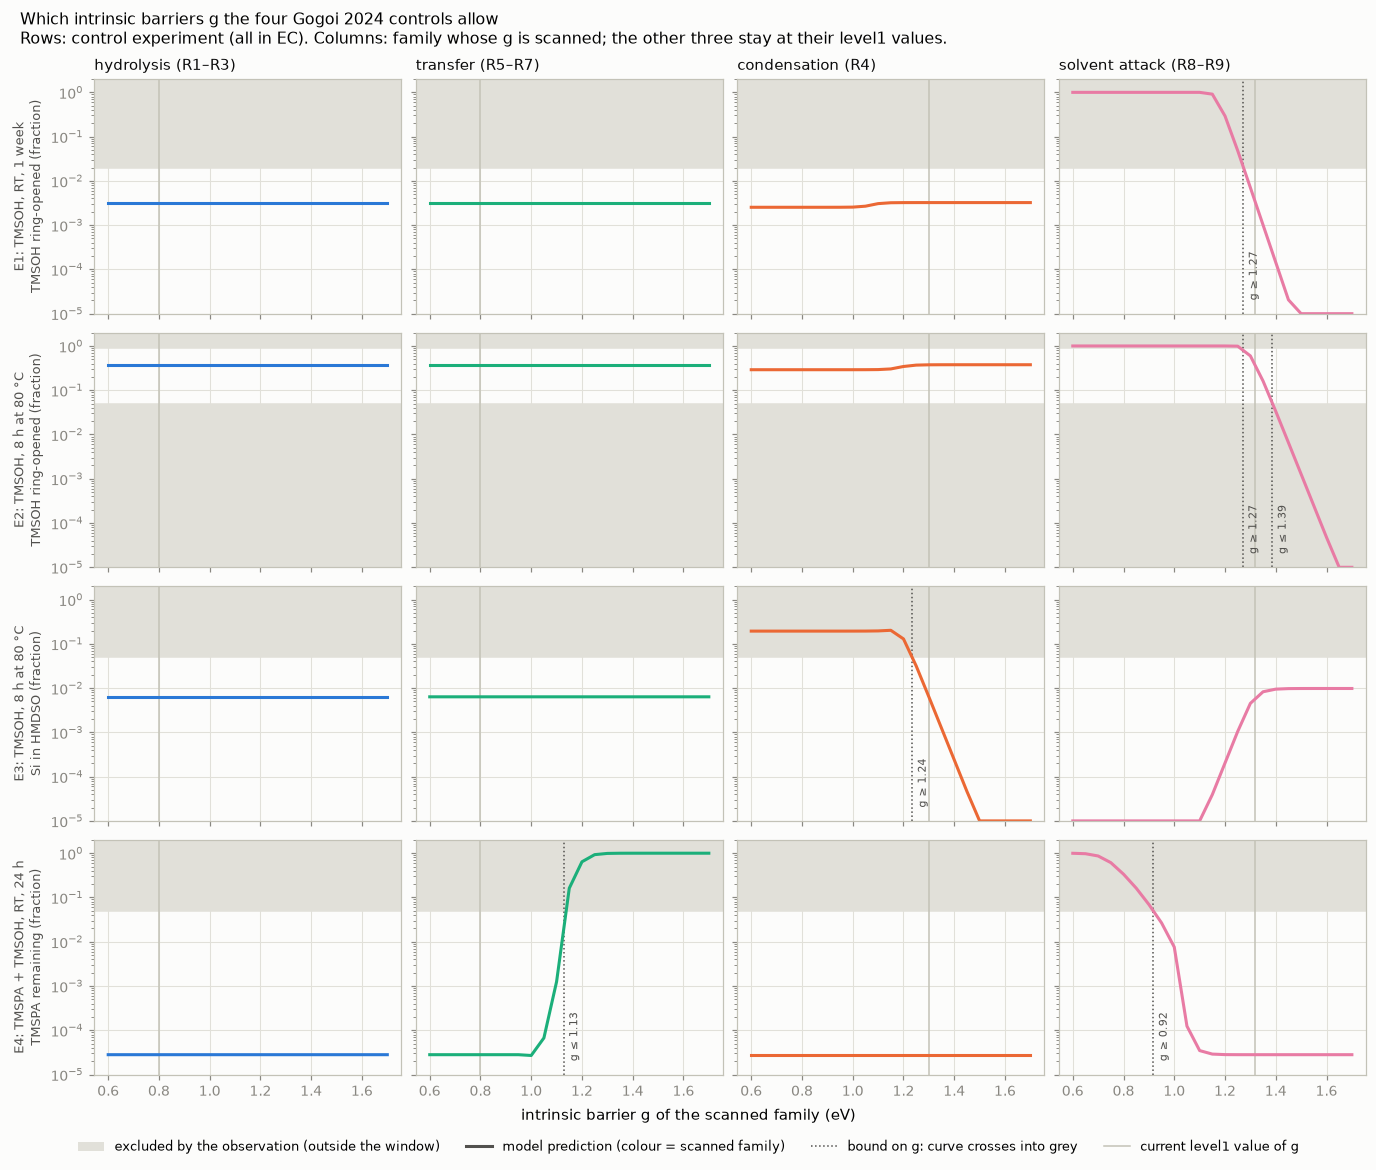

In [6]:
# Finds wich barrier values g agree with the control experiments
scan = scan_family_barriers(model)

# Finds the g values where an experiment prediction stops matching the measured window
bounds = find_barrier_bounds(model, scan=scan)

# Combines the two to give a summary of the feasible intervals for each family
intervals = summarize_feasible_intervals(bounds, scan, model)
display(tables.format_columns(bounds.drop(columns='window edge'),
                              {'g_eV': '.3f', 'T_K': '.0f', 'dG_barrier_at_bound_eV': '.3f'}))
display(tables.format_columns(intervals, {'g low (eV)': '.3f', 'g high (eV)': '.3f', 'current g (eV)': '.2f'}))
design_plots.plot_feasibility_scan(scan, bounds, {f: get_family_parameter(model, f) for f in FAMILIES});


- The x-axis is the barrier g we **assume** for the scanned family. Each point is one complete simulated run of the control with that g, and only its end result is plotted: what Gogoi would saw at the end of the experiment if g had that value. Scanning 100 values of g draws the curve. Low g means a fast reaction; high g, a slow one.

- Gerey region is when results that contradict the observation (outside the window, **assumption**). It depends only on the control, so it is the same across a row. The curve must stay in the white band.

- The g at which the curve crosses into grey (dotted line): beyond it, the prediction stops matching what Gogoi saw (**ASUMPTION**). A flat curve never crosses, so that control is blind to that family. The light solid line is the current `level1` g.

- Worked example: transfer in E4 
  
  $(TMSPA + TMSOH$, 24 h at 25 °C --> Gogoi saw the TMSPA gone, so at most 5 % may remain):

  | assumed g (eV) | TMSPA half-life (approx.) | TMSPA left after 24 h | matches Gogoi? |
  |---|---|---|---|
  | 1.00 | ~1 min | 0.000 | yes |
  | 1.10 | ~40 min | 0.001 | yes |
  | **1.13** | ~2 h | **0.05** | edge |
  | 1.20 | ~31 h | 0.64 | no |
  | 1.30 | ~2 months | 0.99 | no |

  The bound g ≤ 1.13 eV is the *slowest* transfer allowed, not the fastest: any faster value is equally consistent.

- Solvent attack is bounded on both sides: g = 1.27–1.39 eV
  - E1 (no ring-opening after a week at 25 °C) excludes g < 1.27: a faster reaction would have opened more than 2 % of the TMSOH.
  - E2 (clear ring-opening after 8 h at 80 °C) excludes g > 1.39: a slower one would have opened less than 5 %.
  - As an observed barrier: ΔG‡(R8) = 1.25–1.36 eV at 80 °C.

- Condensation has only a lower bound: g ≥ 1.24 eV (ΔG‡(R4) ≥ 1.29 eV at 80 °C). From E3: faster condensation would have turned more than 5 % of the Si into HMDSO. The 5 % limit is assumed.

- Transfer has only an upper bound: g ≤ 1.13 eV** (ΔG‡(R5) ≤ 0.95 eV at 25 °C), from E4 as in the example above. The 24 h is assumed.

- Hydrolysis is not bounded at all, Its curves are flat and white in every row, because no control contains water. This gap is what the experiment plan must close.


- The current `level1` values lie inside every allowed range. This is consistency (not a test): condensation and solvent attack were set from these same controls.


**Limits of the method:** 
One family is scanned at a time with the others fixed, and every bound inherits the window limits and durations we chose (2, 3.1)

### 3.1 How firm are the bounds?

Let's change assumption, low g means a fast reaction, high a slow one
- "Nothing was seen" gives a lower bound g, the reaction can't be faster than tat, or the product would have shown up
  - E3, a stricter detection limit means a smaller amount count as "seen", so the reaction must be even slower
- "The reactant is gone" gives an upper bound on g, the reaction can't be slower than that
  - E4, a shorter waiting time means the reaction had to be faster, so the g bound drops
- Solvent attack: narrower windoe: 20-60%

What this test does: each assumption is made stricter and looser, for example: E3 is run at 2, 5, 10%

   


Three of the windows rest on a detection limit or a reaction time the paper does not state. Each assumption is varied and the bound it sets is recomputed.

In [7]:
controls = {e['id']: e for e in load_experimental_data()['control_experiments']}

def vary_control(exp_id, **changes):
    e = copy.deepcopy(controls[exp_id])
    e.update(changes)
    return e

ASSUMPTIONS = [
    ('condensation', 'E3: HMDSO below 2 % after 8 h at 80 °C', vary_control('E3', high=0.02)),
    ('condensation', 'E3: HMDSO below 5 % (file)', controls['E3']),
    ('condensation', 'E3: HMDSO below 10 %', vary_control('E3', high=0.10)),
    ('transfer', 'E4: TMSPA ≥ 95 % consumed within 1 h', vary_control('E4', t_s=3600)),
    ('transfer', 'E4: within 24 h (file)', controls['E4']),
    ('transfer', 'E4: within 1 week', vary_control('E4', t_s=604800)),
    ('solvent_attack', 'E2: 5–90 % ring-opened after 8 h at 80 °C (file)', controls['E2']),
    ('solvent_attack', 'E2: 20–60 % ring-opened', vary_control('E2', low=0.20, high=0.60)),
    ('solvent_attack', 'E1: below 2 % at RT in 1 week (file)', controls['E1']),
    ('solvent_attack', 'E1: below 10 %', vary_control('E1', high=0.10)),
]
rows = []
for family, assumption, experiment in ASSUMPTIONS:
    found = find_barrier_bounds(model, [family], experiments=[experiment])
    found = found[found['acts'] == 'directly']
    rows.append({'family': family, 'assumption': assumption,
                 'bounds on g (eV)': ';  '.join(f"{b['bound']} {b['g_eV']:.3f}" for _, b in found.iterrows())})
robustness = pd.DataFrame(rows)
robustness

,family,assumption,bounds on g (eV)
0,condensation,E3: HMDSO below 2 % after 8 h at 80 °C,g ≥ 1.265
1,condensation,E3: HMDSO below 5 % (file),g ≥ 1.235
2,condensation,E3: HMDSO below 10 %,g ≥ 1.210
3,transfer,E4: TMSPA ≥ 95 % consumed within 1 h,g ≤ 1.046
4,transfer,E4: within 24 h (file),g ≤ 1.129
5,transfer,E4: within 1 week,g ≤ 1.179
6,solvent_attack,E2: 5–90 % ring-opened after 8 h at 80 °C (file),g ≤ 1.387; g ≥ 1.271
7,solvent_attack,E2: 20–60 % ring-opened,g ≤ 1.343; g ≥ 1.299
8,solvent_attack,E1: below 2 % at RT in 1 week (file),g ≥ 1.273
9,solvent_attack,E1: below 10 %,g ≥ 1.230


(Autogenerated)

**Reading.**
- **The bounds move by 0.03–0.08 eV with the assumptions behind them.**
  - Condensation: the lower bound runs from 1.21 to 1.27 eV as the detection limit goes from 10 % to 2 %.
  - Transfer: the upper bound runs from 1.05 eV (reaction within 1 h) to 1.18 eV (within 1 week).
  - Solvent attack: the interval narrows to 1.30–1.34 eV if 20–60 % ring-opening is assumed.
- **The unknown times and detection limits cost about as much as the bounds are wide.** Asking the authors for the E4 reaction time, or finding it in the SI, would tighten transfer for free.

### 3.2 What two temperatures say about ΔS‡

An observation fixes g at its own temperature: g(T) = g(25 °C) − (T − 25 °C)·ΔS‡. For solvent attack, E1 (25 °C) and E2 (80 °C) therefore constrain a region in the (ΔS‡, g) plane, not a single value.

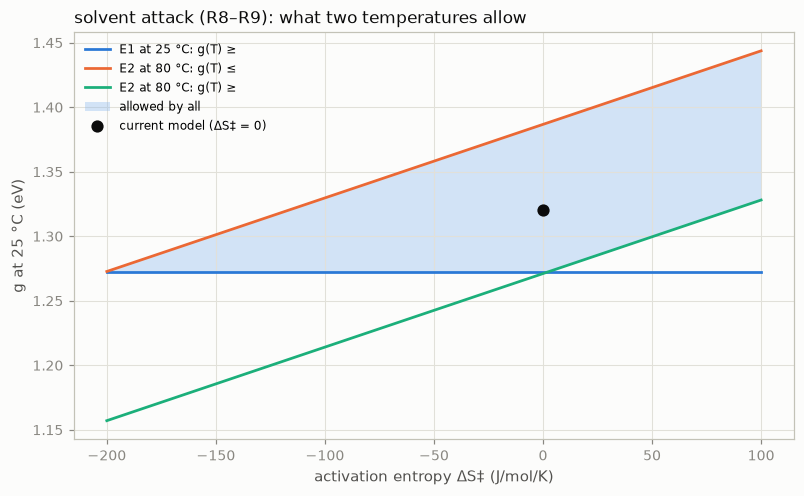

In [8]:
projection = project_bounds_to_entropy(bounds[bounds['acts'] == 'directly'], 'solvent_attack',
                                       np.arange(-200.0, 101.0, 10.0))
design_plots.plot_entropy_constraints(projection, 'solvent_attack',
                                      current=(0.0, get_family_parameter(model, 'solvent_attack')));

- One temperature fixes one combination of g and ΔS‡. E1 (25 °C) bounds g at 25 °C directly, while E2 (80 °C) bounds a line whose slope is the 55 K between the experiments.
- Together they only exclude ΔS‡ below about −200 J/mol/K. Any ΔS‡ from −200 to +100 J/mol/K is allowed, with g at 25 °C between 1.27 and 1.44 eV.
- This is the situation for every family: to learn ΔS‡, the same step must be measured quantitatively at two or more temperatures (7.4).

(not sure if this is interesting)

## 4. Where the model fails: TMSPA with water

Gogoi 2024 also report ³¹P of TMSPA in EC/DEC with four water contents, recorded at an unstated time after mixing, and the 2 vol% sample heated to 80 °C. The windows below are our reading of their text (status `reading`). Because the time is unknown, a parameter set passes only if **one common time** satisfies every sample. The hydrolysis and transfer barriers are varied over and beyond the range the controls allow.

,id,h2o_vol_pct,observation,windows,status
0,W0.5,0.5,"strong TMSPA at -24.60 ppm, weak BMSPA (Fig. 1a)","{'TMSPA': [0.5, None]}",reading
1,W1,1.0,reaction stops at BMSPA while most TMSPA remains unreacted (text only),"{'TMSPA': [0.5, None], 'MMSPA+H3PO4': [None, 0.1]}",reading
2,W2,2.0,"no TMSPA; BMSPA, MMSPA and a strong H3PO4 signal (Fig. 1b)","{'TMSPA': [None, 0.05], 'H3PO4': [0.3, None], 'BMSPA+MMSPA': [0.1, None]}",reading
3,W5,5.0,H3PO4 and a very weak MMSPA signal (Fig. 1c),"{'H3PO4': [0.8, None]}",reading


Parameter sets with at least one common time that satisfies the samples:


,0.5 and 1 vol%,2 and 5 vol%,1 and 2 vol%,all four
sets passing (of 21),15,8,0,0


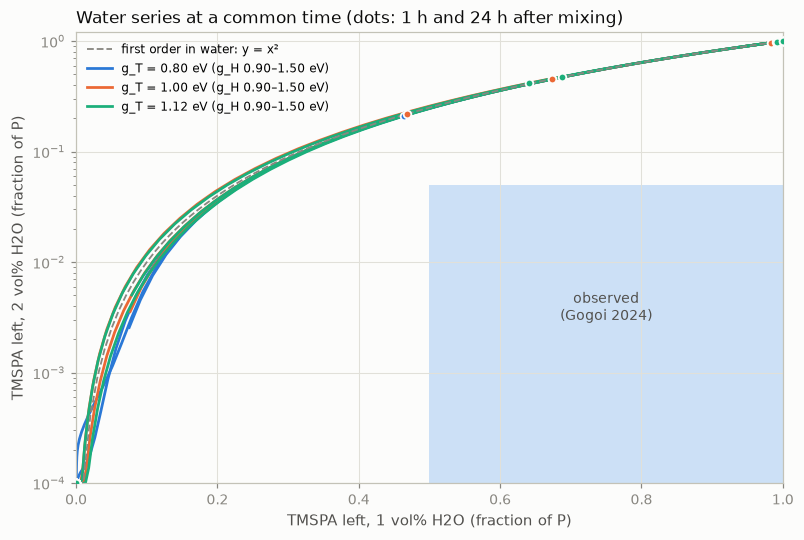

In [9]:
water_series = get_water_series()
display(pd.DataFrame(water_series['samples'])[['id', 'h2o_vol_pct', 'observation', 'windows', 'status']])

G_H_GRID = (0.90, 1.00, 1.10, 1.20, 1.30, 1.40, 1.50)
G_T_GRID = (0.80, 1.00, 1.12)
candidates = [model.with_family_params('hydrolysis', g_eV=gH)
                   .with_family_params('transfer', g_eV=gT, name=f'g_H {gH:.2f}, g_T {gT:.2f}')
              for gT in G_T_GRID for gH in G_H_GRID]
water = evaluate_water_series(candidates, method='BDF')

pairs = {'0.5 and 1 vol%': ['W0.5 ok', 'W1 ok'], '2 and 5 vol%': ['W2 ok', 'W5 ok'],
         '1 and 2 vol%': ['W1 ok', 'W2 ok'], 'all four': ['W0.5 ok', 'W1 ok', 'W2 ok', 'W5 ok']}
water_summary = pd.DataFrame({
    label: water.assign(ok=water[cols].all(axis=1)).groupby('model', sort=False)['ok'].any()
    for label, cols in pairs.items()
})
print('Parameter sets with at least one common time that satisfies the samples:')
display(water_summary.sum().to_frame('sets passing (of %d)' % len(water_summary)).T)

groups = {m.name: f"g_T = {m.name.split('g_T ')[1]} eV (g_H 0.90–1.50 eV)" for m in candidates}
design_plots.plot_water_series_check(water, groups=groups);

1. What Gogoi saw (blue box): TMSPA in EC with two water contents, one ³¹P spectrum each, same (unstated) time after mixing:
   - 1 vol% H₂O → TMSPA barely reacts, in Gogoi mentioned as "Most TMSPA remains unreacted"; we take this as at least 50 % of TMSPA left (x ≥ 0.5).
   - 2 vol% H₂O → TMSPA has reacted. "No TMSPA"; we take this as at most 5 % of TMSPA left (y ≤ 0.05).

   The percentages are a reading of the paper's words, not numbers it reports. The box is where both conditions hold.

2. We expected first order in water (dashed line)
   
   $TMSPA + H₂O$ with rate $k·[TMSPA]·[H₂O]$ 
   
   2x water <-> 2x the rate, (which is the same as letting the 1 vol% sample run twice as long?). So, if a fraction x of TMSPA is left at 1 vol%, x² is left at 2 vol%: $y = x²$ Example: half left at 1 vol% → a quarter left at 2 vol%.

3. The model follows first order. Each curve is one barrier (g) set; moving along it is time after mixing (dots: 1 h and 24 h). Every curve is on y = x², whatever g is: the barrier only sets how fast the point moves along the curve, not where the curve goes.

4. Gogoi's box needs a different order. At x = 0.5, first order gives y = 0.25; Gogoi saw less than 0.05 (remember, it's an interpretation). Doubling the water must speed hydrolysis up more than 4×, not 2×, which is roughly second order in water (rate ∝ [H₂O]², y = x⁴). 

No barrier value can move the curves into the box. This assumes both samples were measured at the same time after mixing; experiments C and D (§6) test the order directly.

In [10]:
heating = evaluate_heating_observation(candidates, rt_hold_h=(1.0, 6.0, 24.0))
consistent_rt = heating[heating['RT ok']]
print(f"{len(consistent_rt)} of {len(heating)} runs give Gogoi's RT spectrum; "
      f"{int(consistent_rt['heating ok'].sum())} of those keep it unchanged up to 80 °C.")
heating_view = consistent_rt.drop(columns=['RT ok'])
tables.format_columns(heating_view, {c: '.2f' for c in heating_view.columns if c.startswith(('RT ', '80 °C', 'max'))})

4 of 63 runs give Gogoi's RT spectrum; 0 of those keep it unchanged up to 80 °C.


,model,RT hold (h),RT TMSPA,RT BMSPA,RT MMSPA,RT H3PO4,80 °C TMSPA,80 °C BMSPA,80 °C MMSPA,80 °C H3PO4,max change,heating ok
7,"g_H 1.10, g_T 0.80",6.00,0.00,0.33,0.25,0.41,0.00,0.00,0.00,1.00,0.59,False
8,"g_H 1.10, g_T 0.80",24.00,0.00,0.02,0.10,0.88,0.00,0.00,0.00,1.00,0.12,False
28,"g_H 1.10, g_T 1.00",6.00,0.00,0.35,0.29,0.36,0.00,0.00,0.00,1.00,0.64,False
50,"g_H 1.10, g_T 1.12",24.00,0.00,0.11,0.16,0.73,0.00,0.00,0.00,1.00,0.27,False


- The model cannot reproduce the water series at any barrier values, at a common time:
  - The low-water pair (0.5 and 1 vol%: TMSPA survives) is reproduced only for hydrolysis g ≥ 1.10 eV.
  - The high-water pair (2 and 5 vol%: no TMSPA, mostly H₃PO₄) is reproduced only for g ≤ 1.10 eV.
  - At g = 1.10 eV the low pair holds only in the first minute and the high pair only after 6–30 h.


- Every barrier traces the same curve, close to y = x²: when the rate is first order in water, TMSPA left at 2 vol% is the square of TMSPA left at 1 vol%, whatever g is. Gogoi's two samples lie far below that curve, as a threshold between 1 and 2 vol%.
- Of the 63 runs, 4 give Gogoi's room-temperature spectrum at 2 vol%, and all 4 drive the remaining BMSPA and MMSPA to H₃PO₄ by 80 °C. Gogoi saw no change.
--> Each hypothesis predicts a different signature in the time-resolved experiments C and D:

(Table autogenerated)
| hypothesis | meaning | signature in C and D |
|---|---|---|
| unequal sampling times | the 1 vol% sample was measured earlier | none: D starts exactly 4× slower than C |
| rate law not first order in water | e.g. acid catalysis by the P–OH products, or water aggregation | sigmoidal TMSPA decay (induction period) in C; D much more than 4× slower |
| equilibrium, or wrong ΔG_rxn (SLV-01) | the ladder stops where equilibrium lies | plateaus that stop moving in time and shift with the water content |
| water unavailable | phase separation (DEC is poorly miscible with water) or water consumed by EC above 40 °C | Karl Fischer after the run and the ¹H mass balance (NB02 §6) show water missing |

- **Consequence:** Fitting only a hydrolysis barrier to the first data set would be premature. Experiments C and D are chosen so that these hypotheses can be told apart.

## 5. What the planned step protocol would show

Peter's protocol (NB02) under the hydrolysis barriers the data still allow: TMSPA left at each acquisition.

hold T (°C),20.0,30.0,40.0,50.0,60.0,70.0,80.0
g_H = 1.00 eV,0.000,0.000,0.000,0.000,0.000,0.0,0.0
g_H = 1.10 eV,0.000,0.000,0.000,0.000,0.000,0.0,0.0
g_H = 1.20 eV,0.001,0.000,0.000,0.000,0.000,0.0,0.0
g_H = 1.25 eV,0.365,0.008,0.000,0.000,0.000,0.0,0.0
g_H = 1.30 eV,0.865,0.501,0.065,0.000,0.000,0.0,0.0
g_H = 1.35 eV,0.980,0.902,0.649,0.193,0.000,0.0,0.0
g_H = 1.40 eV,0.997,0.985,0.934,0.758,0.353,0.0,0.0


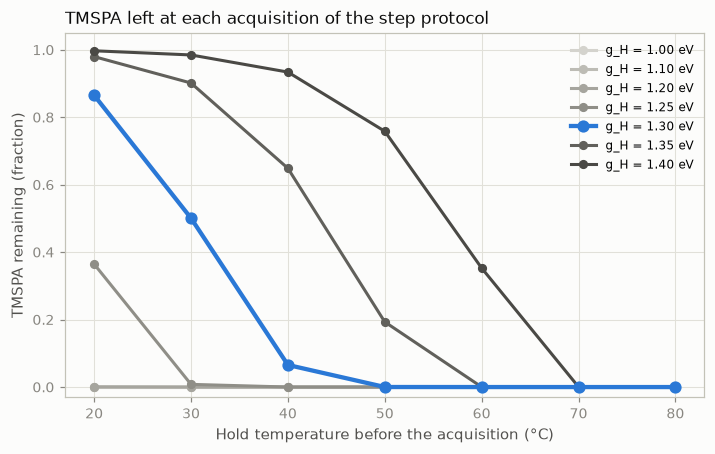

In [11]:
recipe = calculate_recipe_molarities(h2o_vol_frac_stock=0.02, tmspa_vol_frac=0.05)
stages, _ = build_protocol_schedule()
protocol_sweep = {f'g_H = {g:.2f} eV': simulate_protocol(stages, recipe, model=model.with_family_params('hydrolysis', g_eV=g))
                  for g in (1.00, 1.10, 1.20, 1.25, 1.30, 1.35, 1.40)}
display((pd.DataFrame({name: calculate_remaining_fraction(sim) for name, sim in protocol_sweep.items()}).T
         .round(3) + 0.0))
ax = reactor_plots.plot_step_depletion(protocol_sweep, highlight='g_H = 1.30 eV',
                                       title='TMSPA left at each acquisition of the step protocol')
ax.legend(loc='upper right', fontsize=8);

The protocol's outcome depends entirely on the unknown hydrolysis barrier
  - For g ≤ 1.20 eV every TMSPA is gone before the first acquisition (after 8 h at 20 °C), and the series shows only the end of the ladder.
  - For g = 1.25–1.40 eV consumption spreads over the holds, which is the regime Peter's E0 = 1.15 eV was tuned to under the capped BEP.
- It records no spectrum between mixing and the end of the first 8 h hold, where R1 happens for most of the allowed range.

## 6. How to measure: readouts, noise and timing

### 6.1 What each nucleus can read

NMR does not give concentrations. It gives the **area of each peak**. The fit (7) can only use peaks that are really seen in a spectrum.

Rule: a peak is used only if Gogoi 2024 measured it. If they saw several species as one peak, they stay one peak.

In [ ]:
# (Autogenerated)
# Evidence: every measured shift, the peak it defines, and the DFT shift beside it (comparison only)
evidence = tabulate_readout_evidence()
display(tables.format_columns(evidence.drop(columns='site'),
                              {'nuclei per molecule': '.0f', 'DFT δ (ppm)': '+.2f', 'DFT − measured (ppm)': '+.2f'}))

# 2. Readouts: the peak areas the fit uses, derived from the table above
readout_table = pd.DataFrame([
    {'nucleus': n, 'peak': label, 'species in the peak (nuclei per molecule)': ', '.join(f'{sp} ×{k}' for sp, k in members.items())}
    for n, peaks in NMR_READOUTS.items() for label, members in peaks.items()
])
display(readout_table)
for n in NMR_READOUTS:
    print(f"{n:>2}: not read (no measured shift): {', '.join(find_unread_species(n)) or '—'}")

# 3. Acquisition: no source gives these numbers; placeholders used by §7
acquisition_table = pd.DataFrame([
    {'nucleus': n, 'one spectrum every (min)': a['interval_h'] * 60.0, 'σ per integral (mM)': a['sigma_mM'],
     'status': a['status'], 'what replaces it': a['needs']}
    for n, a in DEFAULT_ACQUISITION.items()
])
acquisition_table

,nucleus,species,measured δ (ppm),source (Gogoi 2024),peak read,nuclei per molecule,DFT δ (ppm),DFT − measured (ppm),note
0,P,TMSPA,-24.6,Fig. 1a,TMSPA,1,-22.02,+2.58,
1,P,BMSPA,-15.16 to -13.9,"Fig. 1a, 1b",BMSPA,1,-14.29,+0.24,"-13.90 at 0.5 vol% H2O, -15.16 at 2 vol%"
2,P,MMSPA,-8 to -6.36,"Fig. 1b, 1c",MMSPA,1,-7.04,+0.14,"-6.36 at 2 vol% H2O, -8.00 at 5 vol%"
3,P,H3PO4,-0.33,"Fig. 1b, 1c",H3PO4,1,+0.00,+0.33,
4,Si,TMSPA,25,Fig. 2,xMSPA,3,+27.60,+2.60,"approximate; TMSPA, BMSPA and MMSPA reported as one signal (xMSPA)"
5,Si,BMSPA,25,Fig. 2,xMSPA,2,+28.47,+3.47,approximate; xMSPA
6,Si,MMSPA,25,Fig. 2,xMSPA,1,+30.96,+5.96,approximate; xMSPA
7,Si,TMSOH,14.26 to 15,"Fig. 2, 5c",TMSOH,1,+21.00,+6.37,14.26 in TMSOH/EC/DEC; about 15 in the TMSPA + H2O sample
8,Si,TMSOEG,18.01,Fig. 5c(ii),TMSOEG,1,+21.59,+3.58,"TMS-EG, after 8 h at 80 °C"
9,Si,unassigned,19.08,Fig. 5c(ii),not read,—,—,—,"attributed by the authors to a further EC ring-opening product, possibly with retained carbonate; not assigned"


,nucleus,peak,species in the peak (nuclei per molecule)
0,P,TMSPA,TMSPA ×1
1,P,BMSPA,BMSPA ×1
2,P,MMSPA,MMSPA ×1
3,P,H3PO4,H3PO4 ×1
4,Si,xMSPA,"TMSPA ×3, BMSPA ×2, MMSPA ×1"
5,Si,TMSOH,TMSOH ×1
6,Si,TMSOEG,TMSOEG ×1
7,Si,HMDSO,HMDSO ×2
8,C,TMSOH,TMSOH ×3
9,C,HMDSO,HMDSO ×6


 P: not read (no measured shift): —
Si: not read (no measured shift): TMSOdiEG
 C: not read (no measured shift): TMSPA, BMSPA, MMSPA, TMSOdiEG
 H: not read (no measured shift): TMSOdiEG


,nucleus,one spectrum every (min),σ per integral (mM),status,what replaces it
0,P,5.0,1.0,placeholder,T1 of the silyl phosphates in EC and the S/N of one quantitative ³¹P spectrum (NMR facility)
1,Si,30.0,5.0,placeholder,T1 and the S/N of one inverse-gated ²⁹Si spectrum; Gogoi 2024 did not detect impurity-level HMDSO in ²⁹Si that ¹³C showed
2,C,60.0,5.0,placeholder,T1 and the S/N of one quantitative ¹³C spectrum


**Reading.**
- **³¹P:** 4 separate peaks, one per phosphate. It follows the hydrolysis step by step.
- **²⁹Si:** the 3 phosphates give one peak. TMSOH, TMS-EG and HMDSO are separate, so ²⁹Si sees EC ring-opening.
- **¹³C:** TMSOH, HMDSO and TMS-EG are separate, but only measured without phosphates. Used only in experiment F.
- **¹H:** everything overlaps. Not used.
- **TMSOdiEG** was never measured, so no peak follows it.
- **DFT** is shown only for comparison. It gets the peak positions wrong by up to 6 ppm, so it is not used.
- **The last table is not data.** The time per spectrum and the noise are placeholders, to be confirmed with the NMR facility. They change the size of the errors in §7, not which experiment measures what (§7.2).

### 6.2 When the reaction happens

The half-life of TMSPA over the barriers still allowed and the temperatures where pure EC is liquid (≥ 40 °C). Measurable means between the first spectrum (10 min after mixing) and a 12 h run.

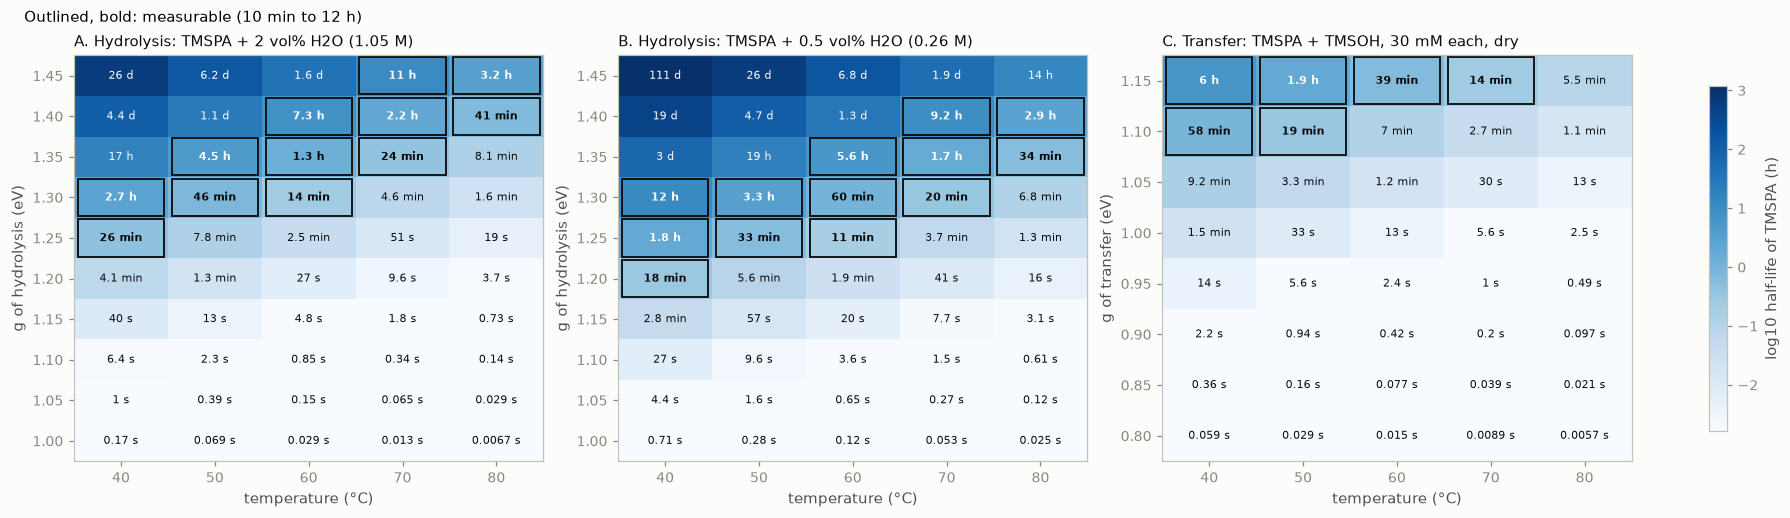

In [13]:
wet = calculate_recipe_molarities(0.02, 0.05)['after']
low = calculate_recipe_molarities(0.005, 0.05)['after']
EC_DRY_M = 1000.0 * DEFAULT_DENSITY_G_ML['EC'] / calculate_molar_mass('EC')   # pure EC, ≈ 15.0 M
c_wet = build_composition(wet['EC'], TMSPA=wet['TMSPA'], H2O=wet['H2O'])
c_low = build_composition(low['EC'], TMSPA=low['TMSPA'], H2O=low['H2O'])
c_dry_transfer = build_composition(EC_DRY_M, TMSPA=0.03, TMSOH=0.03)
c_tmsoh = build_composition(EC_DRY_M, TMSOH=0.45)

T_LIST_C = (40, 50, 60, 70, 80)
half_life_maps = {
    f"A. Hydrolysis: TMSPA + 2 vol% H2O ({wet['H2O']:.2f} M)": calculate_half_life_map(
        model, c_wet, family='hydrolysis', g_values_eV=np.round(np.arange(1.00, 1.451, 0.05), 2), T_C_values=T_LIST_C),
    f"B. Hydrolysis: TMSPA + 0.5 vol% H2O ({low['H2O']:.2f} M)": calculate_half_life_map(
        model, c_low, family='hydrolysis', g_values_eV=np.round(np.arange(1.00, 1.451, 0.05), 2), T_C_values=T_LIST_C),
    'C. Transfer: TMSPA + TMSOH, 30 mM each, dry': calculate_half_life_map(
        model, c_dry_transfer, family='transfer', g_values_eV=np.round(np.arange(0.80, 1.151, 0.05), 2),
        T_C_values=T_LIST_C),
}
for title, table in half_life_maps.items():
    table.index.name = 'g of hydrolysis (eV)' if 'Hydrolysis' in title else 'g of transfer (eV)'
design_plots.plot_half_life_maps(half_life_maps, window_h=(1.0 / 6.0, 12.0));

- With 2 vol% water (A), TMSPA hydrolysis is measurable only in a narrow band. At 40 °C that is g = 1.25–1.30 eV; stepping up to 80 °C extends the window to 1.45 eV. Below 1.20 eV TMSPA is gone within minutes at any temperature where EC is liquid.
- A quarter of the water (B) makes hydrolysis 4× slower. That shifts the window by about 0.04 eV, to 1.20–1.30 eV at 40 °C.
  - If the first run shows TMSPA gone at the first spectrum, the next run must use far less water, roughly tenfold per 0.06 eV.
  - The only hint is Gogoi's 0.5 vol% sample, where TMSPA survives at room temperature. If it was measured an hour or more after mixing, that suggests g ≳ 1.2 eV.
- Dry transfer at 30 mM (C) is measurable only if g ≥ 1.10 eV.** For the `level1` value (0.80 eV) the half-life is well below a second. Lowering the concentration is the only lever, because EC cannot be cooled below 36 °C, and that needs a more sensitive readout. ¹H is not one: it does not separate TMSPA from BMSPA (6.1).

---> The first run should start at 40 °C, record its first spectrum within 10 min, and then step up. The composition of the next run is then chosen from what the first shows.

## 7. Which experiment determines what

Six candidate experiments (A–F, table below). For each one: **if we fit its peak areas (§6.1), how precisely would we get each barrier?** The answer is σ.

**How σ is found.** g has one true value that we don't know. We ask: if g were slightly different, would the spectra look different enough that the noise could not hide it?
1. Simulate the experiment with an assumed true g: the model gives the peak areas at every spectrum.
2. Simulate again with g slightly higher (+5 meV).
3. Compare the difference between the two with the noise of one measurement.
- Big difference compared to the noise → the two values of g can be told apart → **small σ**.
- No difference (e.g. the step never happens during the run) → any g fits the data → **large σ**.

σ is the smallest change in g that still shows above the noise, summed over all spectra. The example below does it by hand.

**Units.** σ is in meV (1 meV = 0.001 eV). At 40 °C, 1 meV ≈ ±4 % on the rate constant; 60 meV ≈ a factor 10.

**Two limits (grey bands in the plots).**
- **σ below 2 meV: below the systematic floor.** σ only counts the noise of the peak areas. The sample temperature (±0.5 K) and the initial water (±5 %) each shift the barrier by about 1–2 meV, and more spectra do not remove that (§7.3). Below 2 meV the real error is about 2 meV. The ±0.5 K and ±5 % are estimates too.
- **σ above 100 meV: not determined.** The calculation starts from "g is known within ±300 meV". If the experiment adds nothing, σ stays at 300 meV. 100 meV is our chosen line: the rate would be uncertain by more than a factor 40.

**One barrier per hydrolysis step** (`HYDROLYSIS_STEPS`). Normally R1, R2 and R3 share one g. Then an experiment that only sees R1 would also "know" R3 through the model, even if R3 never happens in it. Here each step has its own barrier, so a step only counts as measured if the experiment sees it. The other families keep one g (transfer R5–R7 and solvent attack R8–R9 shared).

**"can form, not read":** species the experiment produces that no peak sees (§6.1).

σ is a best case: it assumes the model is right and uses the placeholder noise of §6.1.

In [14]:
DESIGNS = [
    build_step_design('A_step_protocol', "Peter's protocol: holds 20…80 °C, spectra at 20 °C", c_wet,
                      hold_temps_C=(20, 30, 40, 50, 60, 70, 80), purpose='reference'),
    build_isothermal_design('B_wet_40C', 'TMSPA + 2 vol% H2O, in situ at 40 °C', c_wet, T_C=40, duration_h=8,
                            purpose='hydrolysis ladder'),
    build_in_situ_design('C_wet_ramp', 'TMSPA + 2 vol% H2O, in situ 40 → 60 → 80 °C', c_wet,
                         segments=((40, 8), (60, 8), (80, 8)), purpose='hydrolysis ladder, every step'),
    build_isothermal_design('D_low_water_40C', 'TMSPA + 0.5 vol% H2O, in situ at 40 °C', c_low, T_C=40,
                            duration_h=8, purpose='order in water'),
    build_isothermal_design('E_dry_transfer_40C', 'TMSPA + TMSOH, 30 mM each, dry, in situ at 40 °C',
                            c_dry_transfer, T_C=40, duration_h=8, purpose='transfer'),
    build_isothermal_design('F_tmsoh_80C', 'TMSOH 0.45 M, dry, in situ at 80 °C', c_tmsoh, T_C=80, duration_h=24,
                            nuclei=('Si', 'C'), purpose='condensation and solvent attack'),
]
display(describe_designs(DESIGNS))

split_model, split_network, HYDROLYSIS_STEPS = split_family_by_reaction(model, 'hydrolysis')
PARAMETERS = HYDROLYSIS_STEPS + ['transfer', 'condensation', 'solvent_attack']
print('Fitted parameters:', ', '.join(PARAMETERS))

,experiment,purpose,solutes at t = 0,temperature program,spectra,first spectrum (min),duration (h),"can form, not read"
A_step_protocol,"Peter's protocol: holds 20…80 °C, spectra at 20 °C",reference,"TMSPA 149 mM, H2O 1052 mM","holds 20…80 °C × 8 h, spectra at 20 °C","P: 7, Si: 7",540,63.0,Si: TMSOdiEG
B_wet_40C,"TMSPA + 2 vol% H2O, in situ at 40 °C",hydrolysis ladder,"TMSPA 149 mM, H2O 1052 mM",40 °C × 8 h,"P: 95, Si: 16",10,8.0,Si: TMSOdiEG
C_wet_ramp,"TMSPA + 2 vol% H2O, in situ 40 → 60 → 80 °C","hydrolysis ladder, every step","TMSPA 149 mM, H2O 1052 mM",40 °C × 8 h → 60 °C × 8 h → 80 °C × 8 h,"P: 287, Si: 48",10,24.0,Si: TMSOdiEG
D_low_water_40C,"TMSPA + 0.5 vol% H2O, in situ at 40 °C",order in water,"TMSPA 149 mM, H2O 263 mM",40 °C × 8 h,"P: 95, Si: 16",10,8.0,Si: TMSOdiEG
E_dry_transfer_40C,"TMSPA + TMSOH, 30 mM each, dry, in situ at 40 °C",transfer,"TMSPA 30 mM, TMSOH 30 mM",40 °C × 8 h,"P: 95, Si: 16",10,8.0,Si: TMSOdiEG
F_tmsoh_80C,"TMSOH 0.45 M, dry, in situ at 80 °C",condensation and solvent attack,TMSOH 450 mM,80 °C × 24 h,"Si: 48, C: 24",10,24.0,Si: TMSOdiEG; C: TMSOdiEG


Fitted parameters: hydrolysis_R1, hydrolysis_R2, hydrolysis_R3, transfer, condensation, solvent_attack


In [ ]:
# Worked example: experiment B, step R1, true g = 1.25 eV, then 5 meV higher
design_b = next(d for d in DESIGNS if d.name == 'B_wet_40C')
truth_example = split_model
for step in HYDROLYSIS_STEPS:
    truth_example = truth_example.with_family_params(step, g_eV=1.25)
runs = {'TMSPA, true g (mM)': simulate_design(design_b, truth_example, network=split_network),
        'TMSPA, g + 5 meV (mM)': simulate_design(design_b, truth_example.with_family_params('hydrolysis_R1', g_eV=1.255),
                                                  network=split_network)}
t_P = np.asarray(design_b.sampling_h['P'])
rows = [int(np.argmin(abs(t_P - t))) for t in (1 / 6, 0.5, 1.0, 2.0, 4.0)]
sigma_example = pd.DataFrame({label: 1000.0 * run['readouts']['P']['TMSPA'][rows] for label, run in runs.items()},
                             index=pd.Index(np.round(60.0 * t_P[rows]).astype(int), name='time (min)'))
sigma_example['difference (mM)'] = sigma_example.iloc[:, 1] - sigma_example.iloc[:, 0]
sigma_example['noise (mM)'] = DEFAULT_ACQUISITION['P']['sigma_mM']
sigma_example.round(1)

**Reading.** A higher barrier makes R1 slower, so TMSPA lasts longer. 5 meV moves the TMSPA peak by up to about 9.5 mM, far above the 1 mM noise, so real data could tell g = 1.25 from 1.255 eV. Over all 95 spectra this gives σ ≈ 0.1 meV: the value in the 7.1 table for B, R1, true g = 1.25 eV.

### 7.1 Does it depend on the true barrier?

We don't know the real barrier, and how well an experiment measures it depends on it:
- **too low:** the step is over before the first spectrum (10 min), so there is nothing to fit.
- **too high:** the step does not happen during the run, so there is nothing to fit either.
- **in between:** the peaks change while we measure, so the barrier is well measured.

So the calculation is repeated for several "true" barriers:
- **Hydrolysis:** R1, R2 and R3 all set to the same true value, from 1.00 to 1.40 eV (each still fitted separately).
- **Transfer:** true value from 0.80 to 1.10 eV, with hydrolysis at 1.25 eV.

**How to read the plot.**
- **Each panel** is one barrier: R1, R2, R3, transfer.
- **Each colour** is one experiment (A–F, legend below the plot).
- **Each point:** "if the true barrier were x, this experiment would measure it with error σ".
- A good experiment is a line that stays low, in the white band, over the whole x range, because we don't know where the true value is.

σ (meV) at true g_H =               1.00   1.10   1.20   1.25   1.30   1.35  \
parameter      design                                                         
condensation   A_step_protocol     300.0  260.9   19.4    8.6   14.1   66.1   
               B_wet_40C           300.0  278.8  299.8  299.6  295.2  263.3   
               C_wet_ramp          300.0   91.3    4.0    2.8    5.1   15.6   
               D_low_water_40C     300.0  299.9  300.0  299.9  297.2  299.8   
               E_dry_transfer_40C  300.0  300.0  300.0  300.0  300.0  300.0   
               F_tmsoh_80C           4.9    4.9    4.9    4.9    4.9    4.9   
hydrolysis_R1  A_step_protocol     300.0  154.8    7.8    0.3    0.3    0.3   
               B_wet_40C           299.1   15.8    0.3    0.1    0.1    0.2   
               C_wet_ramp          299.0   15.4    0.3    0.1    0.0    0.1   
               D_low_water_40C     202.0   12.6    0.1    0.1    0.2    0.3   
               E_dry_transfer_40C  300.0  300.0  300.0  300.0  300.0  300.0   
               F_tmsoh_80C         300.0  300.0  300.0  300.0  300.0  300.0   
hydrolysis_R2  A_step_protocol      38.9    4.6    1.1    0.9    1.3   64.1   
               B_wet_40C             6.9    0.6    1.5    9.2   56.3  271.5   
               C_wet_ramp            6.8    0.6    0.2    0.1    0.8   15.2   
               D_low_water_40C       4.2    0.5    3.3   14.8  193.8  299.8   
               E_dry_transfer_40C  300.0  300.0  300.0  300.0  300.0  300.0   
               F_tmsoh_80C         300.0  300.0  300.0  300.0  300.0  300.0   
hydrolysis_R3  A_step_protocol       3.2    1.7    2.3    3.3   16.2  202.0   
               B_wet_40C             1.2    0.6    6.8  188.8  300.0  300.0   
               C_wet_ramp            1.1    0.4    0.3    0.8    3.5   39.7   
               D_low_water_40C       1.7    0.8  126.0  300.0  300.0  300.0   
               E_dry_transfer_40C  300.0  300.0  300.0  300.0  300.0  300.0   
               F_tmsoh_80C         300.0  300.0  300.0  300.0  300.0  300.0   
solvent_attack A_step_protocol       0.8    0.8    1.2    2.3    6.7   28.4   
               B_wet_40C            48.6  209.7  300.0  300.0  300.0  300.0   
               C_wet_ramp            0.3    0.3    0.7    1.6    7.1   29.3   
               D_low_water_40C      91.7  294.8  300.0  300.0  300.0  300.0   
               E_dry_transfer_40C  300.0  300.0  300.0  300.0  300.0  300.0   
               F_tmsoh_80C           0.1    0.1    0.1    0.1    0.1    0.1   
transfer       A_step_protocol     294.9  290.6  298.6  297.7  299.8  300.0   
               B_wet_40C           107.1   48.2   88.2  202.8  290.4  299.7   
               C_wet_ramp          106.8   48.2   67.6  183.1  278.9  297.4   
               D_low_water_40C     176.7   86.7  189.8  283.3  299.4  300.0   
               E_dry_transfer_40C  271.2  271.2  271.2  271.2  271.2  271.2   
               F_tmsoh_80C         300.0  300.0  300.0  300.0  300.0  300.0   

σ (meV) at true g_H =               1.40  
parameter      design                     
condensation   A_step_protocol      28.8  
               B_wet_40C           298.4  
               C_wet_ramp           21.5  
               D_low_water_40C     300.0  
               E_dry_transfer_40C  300.0  
               F_tmsoh_80C           4.9  
hydrolysis_R1  A_step_protocol       0.3  
               B_wet_40C             0.5  
               C_wet_ramp            0.1  
               D_low_water_40C       1.7  
               E_dry_transfer_40C  300.0  
               F_tmsoh_80C         300.0  
hydrolysis_R2  A_step_protocol     171.7  
               B_wet_40C           300.0  
               C_wet_ramp          115.4  
               D_low_water_40C     300.0  
               E_dry_transfer_40C  300.0  
               F_tmsoh_80C         300.0  
hydrolysis_R3  A_step_protocol     261.7  
               B_wet_40C           300.0  
               C_wet_ramp          217.0  
        

σ of transfer (meV) at true g_T =,0.8,0.9,1.0,1.1
design,,,,
A_step_protocol,297.7,15.3,16.1,2.0
B_wet_40C,202.8,9.8,25.0,1.2
C_wet_ramp,183.1,5.9,2.3,0.7
D_low_water_40C,283.3,27.3,45.2,1.7
E_dry_transfer_40C,271.2,17.1,3.4,0.5
F_tmsoh_80C,300.0,300.0,300.0,300.0


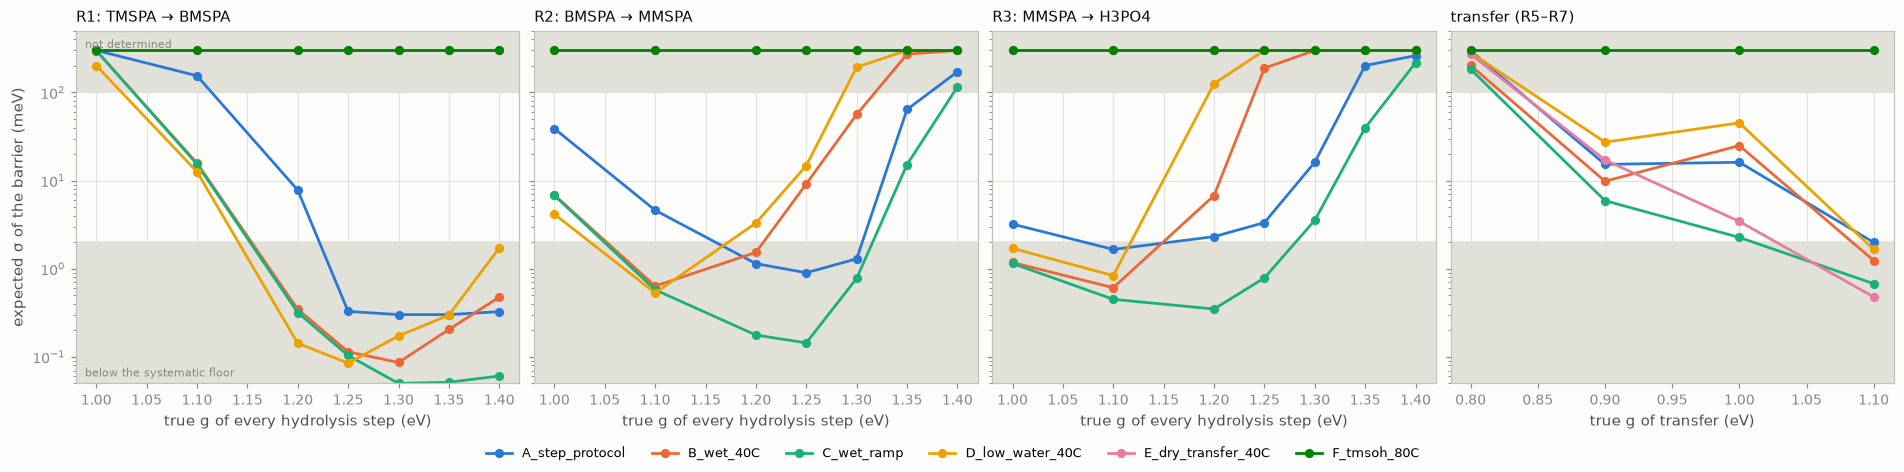

In [15]:
TRUE_G_H = (1.00, 1.10, 1.20, 1.25, 1.30, 1.35, 1.40)
precision_h = scan_design_precision(DESIGNS, split_model, PARAMETERS, vary=HYDROLYSIS_STEPS, values=TRUE_G_H,
                                    network=split_network)
REFERENCE_TRUTH = split_model
for step in HYDROLYSIS_STEPS:
    REFERENCE_TRUTH = REFERENCE_TRUTH.with_family_params(step, g_eV=1.25, name='reference truth')
precision_t = scan_design_precision(DESIGNS, REFERENCE_TRUTH, PARAMETERS, vary='transfer',
                                    values=(0.80, 0.90, 1.00, 1.10), network=split_network)

panels = {f'{step.split("_")[1]}: {label}': (precision_h[precision_h['parameter'] == step], 'true g of every hydrolysis step (eV)')
          for step, label in zip(HYDROLYSIS_STEPS, ('TMSPA → BMSPA', 'BMSPA → MMSPA', 'MMSPA → H3PO4'))}
panels['transfer (R5–R7)'] = (precision_t[precision_t['parameter'] == 'transfer'], 'true g of transfer (eV)')
design_plots.plot_design_precision(panels);
display((precision_h.pivot_table(index=['parameter', 'design'], columns='true value', values='sigma') * 1000.0)
        .round(1).rename_axis(columns='σ (meV) at true g_H ='))
display((precision_t[precision_t['parameter'] == 'transfer']
         .pivot_table(index='design', columns='true value', values='sigma') * 1000.0)
        .round(1).rename_axis(columns='σ of transfer (meV) at true g_T ='))

**Reading.**
- **R1 (TMSPA → BMSPA):** B, C and D measure it if g ≥ 1.10 eV; below that it is over before the first spectrum. A (Peter's protocol) needs g ≥ 1.20 eV, because its first spectrum comes after 9 h.
- **R2 and R3:** the 40 °C runs (B, D) lose them from g ≈ 1.25 eV on: at 40 °C they are too slow for 8 h. C heats to 60 and 80 °C and still measures them at 1.30 eV.
- **Transfer:** measured only if g ≥ 0.90 eV. At 0.80 eV (the `level1` value) it is too fast for every experiment.
- **Condensation and solvent attack:** F measures both, whatever the hydrolysis barrier (it contains no TMSPA).
- **Conclusion:** C is the only experiment that works over the whole plausible range of the hydrolysis barrier.

### 7.2 The plan as a whole

σ of every parameter at the reference truth (all hydrolysis steps 1.25 eV, level1 values otherwise) for each design alone and for combinations. Values in meV.

In [16]:
COMBINATIONS = {
    'plan: C + D + E + F': ['C_wet_ramp', 'D_low_water_40C', 'E_dry_transfer_40C', 'F_tmsoh_80C'],
    'plan without ramp: B + D + E + F': ['B_wet_40C', 'D_low_water_40C', 'E_dry_transfer_40C', 'F_tmsoh_80C'],
}
plan_precision = compare_designs(DESIGNS, REFERENCE_TRUTH, PARAMETERS, combinations=COMBINATIONS,
                                 network=split_network) * 1000.0
plan_precision.round(1)

,hydrolysis_R1,hydrolysis_R2,hydrolysis_R3,transfer,condensation,solvent_attack
A_step_protocol,0.3,0.9,3.3,297.7,8.6,2.3
B_wet_40C,0.1,9.2,188.8,202.8,299.6,300.0
C_wet_ramp,0.1,0.1,0.8,183.1,2.8,1.6
D_low_water_40C,0.1,14.8,300.0,283.3,299.9,300.0
E_dry_transfer_40C,300.0,300.0,300.0,271.2,300.0,300.0
F_tmsoh_80C,300.0,300.0,300.0,300.0,4.9,0.1
plan: C + D + E + F,0.0,0.1,0.7,165.8,2.0,0.1
plan without ramp: B + D + E + F,0.1,3.2,181.8,177.8,4.9,0.1


In [17]:
# The noise per integral is a placeholder (§6.1): repeat with every σ doubled
doubled_noise = {n: {**a, 'sigma_mM': 2.0 * a['sigma_mM']} for n, a in DEFAULT_ACQUISITION.items()}
noise_ratio = compare_designs(DESIGNS, REFERENCE_TRUTH, PARAMETERS, combinations=COMBINATIONS, network=split_network,
                              acquisition=doubled_noise) * 1000.0 / plan_precision
noise_ratio.round(2).rename_axis(columns='σ(noise × 2) / σ(noise × 1)')

σ(noise × 2) / σ(noise × 1),hydrolysis_R1,hydrolysis_R2,hydrolysis_R3,transfer,condensation,solvent_attack
A_step_protocol,2.00,2.00,2.00,1.01,2.00,2.0
B_wet_40C,1.82,1.08,1.35,1.30,1.00,1.0
C_wet_ramp,1.91,1.96,1.99,1.37,1.99,2.0
D_low_water_40C,1.96,1.73,1.00,1.04,1.00,1.0
E_dry_transfer_40C,1.00,1.00,1.00,1.08,1.00,1.0
F_tmsoh_80C,1.00,1.00,1.00,1.00,2.00,2.0
plan: C + D + E + F,1.95,1.98,1.99,1.44,1.99,2.0
plan without ramp: B + D + E + F,1.85,1.47,1.38,1.40,2.00,2.0


**Reading.**
- **The plan C + D + E + F determines every parameter except transfer** at the reference truth, below or near the systematic floor.
- **Replacing the ramp C by the isothermal B loses R3 entirely** (182 meV). The step to 60 and 80 °C in the same run is what reaches the slow end of the ladder.
- **The meV values scale with the placeholder noise.** With every σ per integral doubled, the σ of every determined parameter grows 1.7–2.0×, while the undetermined ones stay at the prior (ratio ≈ 1). Which design determines which barrier does not change. The ratio between ³¹P and ²⁹Si noise is a placeholder as well.
- **Transfer stays undetermined** (166 meV) because the reference truth has it at 0.80 eV, too fast to follow at 30 mM. It is the one family where a smaller concentration and a more sensitive readout could change the answer.

### 7.3 Systematic errors and the step from ΔG‡ to g

The Fisher σ counts only the noise of the integrals. The table adds the systematic errors of a run at 40 °C, and the error that the family g inherits from ΔG_rxn (it does not affect the measured ΔG‡ itself).

In [18]:
dG_R1_40C = REFERENCE_TRUTH.calculate_rates(313.15, network=split_network).loc['R1', 'dG_barrier_f_eV']
sigma_solv = calculate_network_thermo(298.15)['sigma_solv_eV']
error_budget = calculate_barrier_error_budget(
    dG_R1_40C, 40.0, dT_K=0.5, rel_conc_error=0.05,
    sigma_dG_rxn_eV={'if the MD σ are standard errors': 0.02,
                     'if the MD σ are raw stds, network median': float(sigma_solv.median())})
print(f'ΔG‡(R1) at 40 °C in the reference truth: {dG_R1_40C:.3f} eV')
error_budget.round(2)

ΔG‡(R1) at 40 °C in the reference truth: 1.024 eV


,on measured ΔG‡ (meV),on family g (meV),factor on k
sample temperature ±0.5 K,1.68,1.68,1.06
initial co-reactant concentration ±5 %,1.32,1.32,1.05
ΔG_rxn ±0.02 eV (if the MD σ are standard errors),0.00,10.00,1.00
"ΔG_rxn ±0.25 eV (if the MD σ are raw stds, network median)",0.00,125.22,1.00


**Reading.**
- **The systematic floor of a measured barrier is about 2 meV.** It comes from ±0.5 K in the sample temperature and ±5 % in the initial water, which is why Karl Fischer is required. Each is a factor of about 1.05 in the rate constant, well above the noise-limited σ of the best designs. **σ below 2 meV in §7.1 means "limited by systematics", not "better".**
- **The family g inherits the ΔG_rxn error.** That is 10 meV if the MD σ are standard errors, but 125 meV if they are raw standard deviations (SLV-01). In the second case the measured ΔG‡ of each step is precise, but the family g, and every prediction that uses the Marcus relation to transfer it to another reaction, is not.
- **Report the fitted ΔG‡ per step as the primary result**, and derive g only once SLV-01 is resolved.

### 7.4 How many temperatures for ΔS‡

Barriers measured at several temperatures, each to ±3 meV (systematic floor plus noise), give ΔH‡ and ΔS‡ by linear regression.

In [19]:
eyring = calculate_eyring_precision({
    'two, 40 and 60 °C': (40, 60),
    'three, 40 to 80 °C': (40, 60, 80),
    'five, 40 to 80 °C': (40, 50, 60, 70, 80),
    'three, 60 to 80 °C': (60, 70, 80),
}, sigma_g_eV=0.003)
tables.format_columns(eyring, {'span (K)': '.0f', 'σ ΔS‡ (J/mol/K)': '.0f', 'σ ΔH‡ (kJ/mol)': '.1f'})

,temperatures (°C),n,span (K),σ ΔS‡ (J/mol/K),σ ΔH‡ (kJ/mol)
"two, 40 and 60 °C","40, 60",2,20,20,6.6
"three, 40 to 80 °C","40, 60, 80",3,40,10,3.4
"five, 40 to 80 °C","40, 50, 60, 70, 80",5,40,9,3.1
"three, 60 to 80 °C","60, 70, 80",3,20,20,7.0


**Reading.**
- **The temperature span matters more than the number of temperatures.** Three temperatures across 40 K give σ(ΔS‡) ≈ 10 J/mol/K and σ(ΔH‡) ≈ 3 kJ/mol. Two temperatures 20 K apart give 20 J/mol/K. Five temperatures on the same span gain little.
- **The ramp C gives the later steps (R2, R3) over two or three temperatures within one run.** R1 reacts only where it is fast enough, so its temperature dependence needs a repeat of C at a second starting temperature (priority 5).

### 7.5 Fitting ΔS‡ together with g

§7.1–7.2 fix ΔS‡ = 0, so a barrier measured at 40 °C is assumed to hold at 60 and 80 °C. Here ΔS‡ of each hydrolysis step is fitted as well, which is what the real fit must do. g is referenced at 60 °C, the middle of the ramp, so g and ΔS‡ are as uncorrelated as the data allow. Two second-temperature runs are compared: **C′** (C started at 50 °C) and **D′** (D at 50 °C, which completes a 2 × 2 design in water and temperature). σ(ΔS‡) close to the 100 J/mol/K prior means not determined.

In [20]:
T_MID_K = 333.15   # 60 °C: reference temperature of g for the hydrolysis steps
by_name = {d.name: d for d in DESIGNS}
DESIGNS_DS = [
    by_name['C_wet_ramp'], by_name['D_low_water_40C'],
    build_in_situ_design('C2_wet_ramp_50C', 'C′: TMSPA + 2 vol% H2O, in situ 50 → 70 → 80 °C', c_wet,
                         segments=((50, 8), (70, 8), (80, 8)), purpose='ΔS‡ of R1'),
    build_isothermal_design('D2_low_water_50C', 'D′: TMSPA + 0.5 vol% H2O, in situ at 50 °C', c_low, T_C=50,
                            duration_h=8, purpose='ΔS‡ of R1; order in water at a second T'),
]
COMBINATIONS_DS = {'C + D': ['C_wet_ramp', 'D_low_water_40C'],
                   'C + C′': ['C_wet_ramp', 'C2_wet_ramp_50C'],
                   'C + D + D′': ['C_wet_ramp', 'D_low_water_40C', 'D2_low_water_50C']}
PARAMETERS_DS = [p for step in HYDROLYSIS_STEPS for p in (step, f'{step}:dS')] + ['transfer', 'condensation', 'solvent_attack']


def hydrolysis_truth(g_eV, dS_J_mol_K=0.0):
    """split_model with every hydrolysis step at g (referenced at 60 °C) and ΔS‡."""
    truth = split_model
    for step in HYDROLYSIS_STEPS:
        truth = truth.with_family_params(step, g_eV=g_eV, dS_act_J_mol_K=dS_J_mol_K, T_ref_K=T_MID_K)
    return truth


TRUTHS_DS = {'g 1.20, ΔS‡ 0': (1.20, 0.0), 'g 1.25, ΔS‡ 0': (1.25, 0.0), 'g 1.30, ΔS‡ 0': (1.30, 0.0),
             'g 1.25, ΔS‡ −50': (1.25, -50.0)}
precision_ds = pd.concat([
    compare_designs(DESIGNS_DS, hydrolysis_truth(g, dS), PARAMETERS_DS, combinations=COMBINATIONS_DS,
                    network=split_network).assign(truth=label)
    for label, (g, dS) in TRUTHS_DS.items()
]).rename_axis('design').reset_index()

shown = precision_ds[precision_ds['design'].isin(['C_wet_ramp', *COMBINATIONS_DS])].set_index(['truth', 'design'])
steps = [s.split('_')[1] for s in HYDROLYSIS_STEPS]
sigma_g = (shown[HYDROLYSIS_STEPS] * 1000.0).set_axis(steps, axis=1)
sigma_dS = shown[[f'{s}:dS' for s in HYDROLYSIS_STEPS]].set_axis(steps, axis=1)
pd.concat({'σ g at 60 °C (meV)': sigma_g.round(1), 'σ ΔS‡ (J/mol/K)': sigma_dS.round(0)}, axis=1)

σ g at 60 °C (meV)            σ ΔS‡ (J/mol/K)       \
                                           R1   R2    R3              R1   R2   
truth           design                                                          
g 1.20, ΔS‡ 0   C_wet_ramp               15.7  0.5   1.0            75.0  3.0   
                C + D                     9.8  0.5   1.0            47.0  3.0   
                C + C′                    3.1  0.4   0.5            15.0  2.0   
                C + D + D′                0.5  0.3   0.8             3.0  3.0   
g 1.25, ΔS‡ 0   C_wet_ramp                8.5  0.5   2.1            41.0  6.0   
                C + D                     8.2  0.5   2.1            39.0  6.0   
                C + C′                    0.4  0.2   0.8             2.0  2.0   
                C + D + D′                0.2  0.4   2.0             1.0  6.0   
g 1.30, ΔS‡ 0   C_wet_ramp                1.1  1.7  17.1             5.0  8.0   
                C + D                     1.1  1.7  17.0             5.0  7.0   
                C + C′                    0.2  0.8   2.7             1.0  5.0   
                C + D + D′                0.1  1.6  16.1             1.0  7.0   
g 1.25, ΔS‡ −50 C_wet_ramp               10.0  0.6   2.1            48.0  5.0   
                C + D                     8.9  0.6   2.1            43.0  5.0   
                C + C′                    0.4  0.2   0.8             2.0  2.0   
                C + D + D′                0.2  0.5   2.0             1.0  5.0   

                                  
                              R3  
truth           design            
g 1.20, ΔS‡ 0   C_wet_ramp  10.0  
                C + D       10.0  
                C + C′       3.0  
                C + D + D′   9.0  
g 1.25, ΔS‡ 0   C_wet_ramp   7.0  
                C + D        7.0  
                C + C′       4.0  
                C + D + D′   7.0  
g 1.30, ΔS‡ 0   C_wet_ramp  74.0  
                C + D       73.0  
                C + C′      12.0  
                C + D + D′  69.0  
g 1.25, ΔS‡ −50 C_wet_ramp   6.0  
                C + D        6.0  
                C + C′       4.0  
                C + D + D′   6.0

**Reading.**
- **C alone gives ΔS‡ of R2 and R3** (σ 3–10 J/mol/K) for g ≤ 1.25 eV, because both steps run through 60 and 80 °C. At 1.30 eV R3 only starts at 80 °C and its ΔS‡ is lost.
- **C alone does not give ΔS‡ of R1** (σ 40–75 J/mol/K, against a 100 J/mol/K prior). R1 is over within the 40 °C segment, so it is seen at one temperature only. The exception is g ≈ 1.30 eV, where R1 lasts into 60 °C.
- **The precision of §7.1 for R1 assumed ΔS‡ = 0.** With ΔS‡ free, σ(g of R1 at 60 °C) grows from ~0.1 to 8–16 meV. That is the cost of carrying the 40 °C barrier 20 K further with an unknown ΔS‡ (20 K × σΔS‡). The barrier at 40 °C itself stays precise.
- **C′ fixes R1:** C + C′ gives σ(ΔS‡ of R1) ≤ 15 J/mol/K for every truth tested, and also recovers R3 at 1.30 eV. D′ fixes R1 as well, but not R3; its extra value is the order in water at a second temperature. **C′ is the better second-temperature run; D′ is optional.**

## 8. What the first experiment would look like

Design C for two truths 0.05 eV apart (lines), and one synthetic measurement of the first truth with the assumed noise (dots).

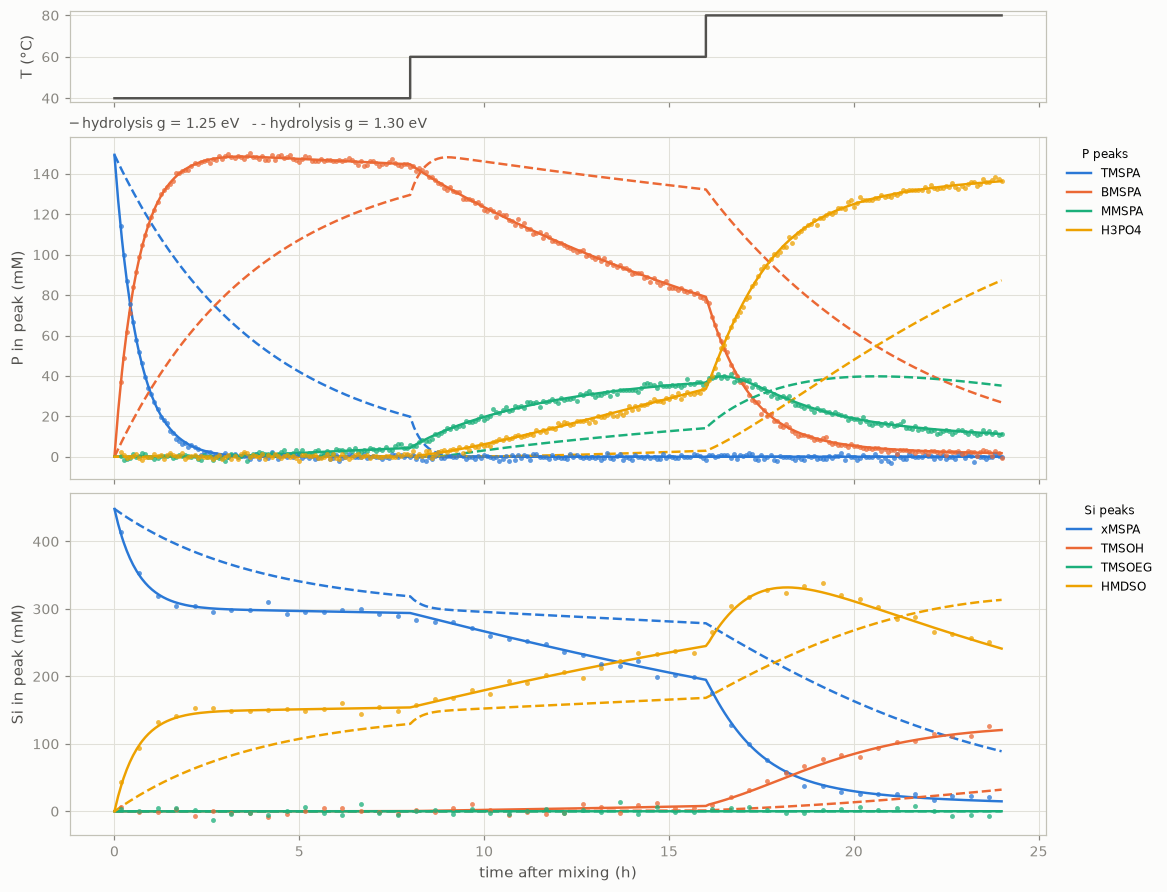

In [21]:
design_c = next(d for d in DESIGNS if d.name == 'C_wet_ramp')
truths = {}
for g in (1.25, 1.30):
    truth = split_model
    for step in HYDROLYSIS_STEPS:
        truth = truth.with_family_params(step, g_eV=g)
    truths[f'hydrolysis g = {g:.2f} eV'] = truth
design_runs = {label: simulate_design(design_c, truth, network=split_network) for label, truth in truths.items()}
synthetic = {label: add_readout_noise(run) for label, run in design_runs.items()}
design_plots.plot_design_readouts(design_runs, synthetic);

**Reading.**
- **At the reference truth (g = 1.25 eV, solid lines):**
  - TMSPA turns into BMSPA within about an hour at 40 °C.
  - BMSPA persists until the 60 °C step turns it into MMSPA and H₃PO₄, and the ladder completes at 80 °C.
  - HMDSO appears together with BMSPA: in this model every TMSOH released is captured at once by transfer, which matches the strong HMDSO line Gogoi saw in the 2 vol% sample.
  - TMSOH and the glycols rise only at 80 °C.
- **A barrier 0.05 eV higher (dashed) shifts every stage visibly.** At the assumed noise the difference is many times the scatter of the points. It is also the kind of data that tests §4: an induction period or a stalled ladder would be obvious by eye.

### 8.1 CO₂ in a sealed tube

EC ring-opening (R8, R9) releases CO₂, mostly at 80 °C. The table gives the CO₂ at the end of C (for three hydrolysis barriers) and F, and the headspace pressure if all of it left the liquid. That is an upper bound: the real pressure is lower because part of the CO₂ stays dissolved (Henry's law), but the solubility of CO₂ in EC at 80 °C is not yet in our references. The tube volumes are assumptions; Gogoi 2024 used 150 µL of sample and do not state the headspace.

In [22]:
TUBES = {'0.60 mL liquid / 1.0 mL gas': (0.60, 1.0),    # assumed geometries of a sealed 5 mm tube
         '0.60 mL liquid / 2.0 mL gas': (0.60, 2.0),
         '0.15 mL liquid / 1.0 mL gas': (0.15, 1.0)}
co2_runs = {f'C, hydrolysis g = {g:.2f} eV': (by_name['C_wet_ramp'], hydrolysis_truth(g)) for g in (1.20, 1.25, 1.30)}
co2_runs['F, TMSOH 0.45 M'] = (by_name['F_tmsoh_80C'], split_model)

rows = {}
for label, (design, truth) in co2_runs.items():
    run = simulate_design(design, truth, network=split_network)
    co2_M, T_end_K = run['C_M'][run['idx']['CO2'], -1], run['T_C'][-1] + 273.15
    rows[label] = {'final CO₂ (mM)': 1000.0 * co2_M,
                   **{f'p max (bar), {tube}': calculate_worst_case_pressure_bar(co2_M, v_liq, v_gas, T_end_K)
                      for tube, (v_liq, v_gas) in TUBES.items()}}
co2_pressure = pd.DataFrame.from_dict(rows, orient='index')
co2_pressure.round(1)

,final CO₂ (mM),"p max (bar), 0.60 mL liquid / 1.0 mL gas","p max (bar), 0.60 mL liquid / 2.0 mL gas","p max (bar), 0.15 mL liquid / 1.0 mL gas"
"C, hydrolysis g = 1.20 eV",341.6,6.0,3.0,1.5
"C, hydrolysis g = 1.25 eV",143.1,2.5,1.3,0.6
"C, hydrolysis g = 1.30 eV",27.2,0.5,0.2,0.1
"F, TMSOH 0.45 M",851.1,15.0,7.5,3.7


**Reading.**
- **F is the critical run.** 0.45 M TMSOH at 80 °C for 24 h ends with ≈ 0.85 M CO₂, close to two CO₂ per TMSOH (R8, then R9). With 0.6 mL of liquid and 1 mL of gas that is up to 15 bar. C releases 0.03–0.34 M, more when hydrolysis is faster, so up to 6 bar.
- **The upper bound scales as [CO₂]·V_liquid / V_gas.** Less liquid, more headspace, or less TMSOH in F (pressure is proportional to [TMSOH]₀) all lower it. The pressure rating of the tube must come from the NMR facility.
- **CO₂ is not a readout (§6.1).** It has no measured ¹³C shift, and with a headspace the dissolved CO₂ underestimates ring-opening. Solvent attack is read from TMSOH and TMS-EG (²⁹Si, ¹³C methyl); TMSOdiEG has no measured peak.

## 9. Tentative plan

In order of priority. Each experiment has one main target and a built-in control; the decision column says what to change if it fails.

In [23]:
plan = pd.DataFrame([
    ['1', 'C: TMSPA + 2 vol% H2O, in situ 40 → 60 → 80 °C (8 h each)', '³¹P every 5 min, ²⁹Si every 30 min',
     'g of R1, R2, R3 separately; transfer if g_T ≥ 0.9', 'Karl Fischer before and after; t = 0 spectrum'],
    ['2', 'D: same with 0.5 vol% H2O', 'as 1', 'order in water; the water-series threshold (§4)',
     'if R1 is not ~4× slower than in 1, the rate law is wrong'],
    ['3', 'E: TMSPA + TMSOH, 30 mM each, dry, 40 °C', '³¹P every 5 min, ²⁹Si every 30 min',
     'g of transfer, or a tighter upper bound', 'if consumed before the first spectrum: halve the concentration'],
    ['4', 'F: TMSOH 0.45 M, dry, 80 °C, 24 h', '²⁹Si every 30 min, ¹³C every 1 h',
     'condensation and solvent attack, and the E1–E3 windows as curves', 'up to 15 bar CO₂ if sealed (§8.1): ask for the tube rating'],
    ['5', 'C′: repeat 1 started at 50 °C (50 → 70 → 80 °C)', 'as 1', 'ΔH‡, ΔS‡ of R1 (R2, R3 already from 1)',
     'without it ΔS‡ of R1 stays undetermined (§7.5)'],
], columns=['priority', 'experiment', 'nuclei and cadence', 'determines', 'decision / control'])
plan

,priority,experiment,nuclei and cadence,determines,decision / control
0,1,"C: TMSPA + 2 vol% H2O, in situ 40 → 60 → 80 °C (8 h each)","³¹P every 5 min, ²⁹Si every 30 min","g of R1, R2, R3 separately; transfer if g_T ≥ 0.9",Karl Fischer before and after; t = 0 spectrum
1,2,D: same with 0.5 vol% H2O,as 1,order in water; the water-series threshold (§4),"if R1 is not ~4× slower than in 1, the rate law is wrong"
2,3,"E: TMSPA + TMSOH, 30 mM each, dry, 40 °C","³¹P every 5 min, ²⁹Si every 30 min","g of transfer, or a tighter upper bound",if consumed before the first spectrum: halve the concentration
3,4,"F: TMSOH 0.45 M, dry, 80 °C, 24 h","²⁹Si every 30 min, ¹³C every 1 h","condensation and solvent attack, and the E1–E3 windows as curves",up to 15 bar CO₂ if sealed (§8.1): ask for the tube rating
4,5,C′: repeat 1 started at 50 °C (50 → 70 → 80 °C),as 1,"ΔH‡, ΔS‡ of R1 (R2, R3 already from 1)",without it ΔS‡ of R1 stays undetermined (§7.5)


**Questions for Jan Felix (NMR)**
1. Can spectra be recorded in the magnet at 40–80 °C? How soon after mixing can the first one start, and how accurate is the sample temperature (±0.5 K assumed)?
2. Quantitative ³¹P: what are the T₁ of the silyl phosphates in EC? Is one spectrum every 5 min with about 1 mM error per integral realistic?
3. Quantitative ²⁹Si: how long does an inverse-gated spectrum take? Is a relaxation agent (e.g. Cr(acac)₃) acceptable, or could it react? Gogoi resolved TMSOH (14.3 ppm) and TMS-EG (18.0 ppm). Is their unassigned line at 19.1 ppm the second ring-opening product (TMSOdiEG)?
4. Gogoi report the TMS methyl ¹H of TMSPA, BMSPA and MMSPA at one shift, and TMSOH with HMDSO at another (§6.1). Would a higher field separate them? Only then could ¹H follow the fast transfer step at millimolar concentrations.
5. Can ³¹P and ²⁹Si be interleaved in one run? Which lock and reference (Gogoi used a DMSO-d₆ insert)? Is the tube sealed, and how much headspace does it have (CO₂)?
6. What is the data format: pseudo-2D arrays? We need integrals per peak and per time, with their uncertainties.
7. Reference spectra: the methyl ¹³C of TMSPA, BMSPA and MMSPA and every shift of TMSOdiEG were never measured. Spectra of the pure compounds in EC would turn them into readouts (§6.1).

**Questions for Erik (samples)**
- Karl Fischer water before adding TMSPA and after the run.
- Purity of the TMSPA batch (Gogoi found BMSPA in "pure" TMSPA).
- Pure EC or EC/DEC? Is the sample one phase?
- The exact reaction time of the TMSPA + TMSOH control (E4).

**What we can already state**
- A single global barrier is excluded.
- Solvent attack needs g = 1.27–1.39 eV.
- Uncatalysed condensation is slow (g ≥ 1.24 eV).
- Transfer is fast at room temperature (g ≤ 1.13 eV).
- Hydrolysis is not constrained, and the existing water-series observations contradict a hydrolysis step that is first order in water in one homogeneous phase.

## 10. Export

Tables of this notebook to `notebooks/results/03/` as CSV (ignored by git).

In [24]:
OUT_DIR = REPO / 'notebooks' / 'results' / '03'
OUT_DIR.mkdir(parents=True, exist_ok=True)
exports = {
    'feasibility_scan.csv': scan,
    'barrier_bounds.csv': bounds,
    'feasible_intervals.csv': intervals,
    'bound_assumptions.csv': robustness,
    'water_series.csv': water,
    'heating_check.csv': heating,
    'design_list.csv': describe_designs(DESIGNS),
    'design_precision_hydrolysis.csv': precision_h,
    'design_precision_transfer.csv': precision_t,
    'plan_precision_meV.csv': plan_precision,
    'error_budget.csv': error_budget,
    'eyring_precision.csv': eyring,
    'design_precision_with_entropy.csv': precision_ds,
    'co2_pressure.csv': co2_pressure,
    'plan.csv': plan,
}
for title, table in half_life_maps.items():
    exports[f"half_life_h_{title.split('.')[0]}.csv"] = table
for name, df in exports.items():
    df.to_csv(OUT_DIR / name)
    print(f'notebooks/results/03/{name}: {len(df)} rows')

notebooks/results/03/feasibility_scan.csv: 368 rows
notebooks/results/03/barrier_bounds.csv: 6 rows
notebooks/results/03/feasible_intervals.csv: 4 rows
notebooks/results/03/bound_assumptions.csv: 10 rows
notebooks/results/03/water_series.csv: 2520 rows
notebooks/results/03/heating_check.csv: 63 rows
notebooks/results/03/design_list.csv: 6 rows
notebooks/results/03/design_precision_hydrolysis.csv: 252 rows
notebooks/results/03/design_precision_transfer.csv: 144 rows
notebooks/results/03/plan_precision_meV.csv: 8 rows
notebooks/results/03/error_budget.csv: 4 rows
notebooks/results/03/eyring_precision.csv: 4 rows
notebooks/results/03/design_precision_with_entropy.csv: 28 rows
notebooks/results/03/co2_pressure.csv: 4 rows
notebooks/results/03/plan.csv: 5 rows
notebooks/results/03/half_life_h_A.csv: 10 rows
notebooks/results/03/half_life_h_B.csv: 10 rows
notebooks/results/03/half_life_h_C.csv: 8 rows
